# Lab06 - EDA - Phân tích khám phá dữ liệu

## ___Khảo sát trên tập dữ liệu Pima India về bệnh tiểu đường___

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## ___TỔNG QUAN DỮ LIỆU___

### Đọc dữ liệu từ dataset

In [ ]:
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

df = pd.read_csv('pima-indians-diabetes.csv', names=columns)

In [51]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


### Kiểm tra dữ liệu trùng

In [52]:
duplicates = df.duplicated()
print("Số dòng trùng lặp:", duplicates.sum())

df_cleaned = df.drop_duplicates()
print("Số dòng sau khi loại bỏ trùng lặp:", df_cleaned.shape)

Số dòng trùng lặp: 0
Số dòng sau khi loại bỏ trùng lặp: (768, 9)


### Kiểm tra và loại bỏ dữ liệu ngoại lệ

In [53]:
physiological_ranges = {
    'Pregnancies': (0, 20),
    'Glucose': (40, 200),
    'BloodPressure': (20, 140),
    'SkinThickness': (5, 99),
    'Insulin': (15, 846),
    'BMI': (15, 60),
    'DiabetesPedigreeFunction': (0.0, 2.5),
    'Age': (10, 100)
}

In [54]:
def detect_physiological_errors(df, physiological_ranges):
    if not isinstance(df, pd.DataFrame):
        raise TypeError('df must be a pandas DataFrame')
    if not isinstance(physiological_ranges, dict):
        raise TypeError('physiological_ranges must be a dict')
    errors = {}
    for col, valid_range in physiological_ranges.items():
        if col not in df.columns:
            continue
        if not (isinstance(valid_range, (tuple, list)) and len(valid_range) == 2):
            raise ValueError(f'Range for {col} must be tuple/list (min, max)')
        min_val, max_val = valid_range
        col_values = df[col]
        invalid_mask = col_values.notna() & ((col_values < min_val) | (col_values > max_val))
        invalid_values = col_values[invalid_mask]
        if not invalid_values.empty:
            errors[col] = {
                'count': int(invalid_values.shape[0]),
                'min_actual': float(col_values.min()) if pd.notna(col_values.min()) else None,
                'max_actual': float(col_values.max()) if pd.notna(col_values.max()) else None,
                'problem_values': sorted(set(invalid_values.tolist()))
            }
    return errors

In [55]:
errors = detect_physiological_errors(df, physiological_ranges)
print("=== Dữ liệu lỗi phát hiện ===")
for col, info in errors.items():
        print(f"{col}: {info['count']} giá trị lỗi")
        print(f" -Range thực tế: {info['min_actual']} - {info['max_actual']}")
        print(f" -Giá trị có vấn đề: {info['problem_values']}")

=== Dữ liệu lỗi phát hiện ===
Glucose: 5 giá trị lỗi
 -Range thực tế: 0.0 - 199.0
 -Giá trị có vấn đề: [0]
BloodPressure: 35 giá trị lỗi
 -Range thực tế: 0.0 - 122.0
 -Giá trị có vấn đề: [0]
SkinThickness: 227 giá trị lỗi
 -Range thực tế: 0.0 - 99.0
 -Giá trị có vấn đề: [0]
Insulin: 375 giá trị lỗi
 -Range thực tế: 0.0 - 846.0
 -Giá trị có vấn đề: [0, 14]
BMI: 12 giá trị lỗi
 -Range thực tế: 0.0 - 67.1
 -Giá trị có vấn đề: [0.0, 67.1]


### Xử lý các giá trị bằng 0

In [56]:
def handle_zero_values(df):
    zero_sensitive_columns = ['Insulin', 'SkinThickness']
    for col in zero_sensitive_columns:
        zero_mask = df[col] == 0
        if zero_mask.any():
            print(f"Phát hiện {zero_mask.sum()} giá trị 0 trong {col}")
            median_val = df[col][df[col] > 0].median()
            df.loc[zero_mask, col] = median_val
            print(f" -> Đã thay thế bằng median: {median_val:.2f}")
    return df
df_final = handle_zero_values(df_cleaned)

Phát hiện 374 giá trị 0 trong Insulin
 -> Đã thay thế bằng median: 125.00
Phát hiện 227 giá trị 0 trong SkinThickness
 -> Đã thay thế bằng median: 29.00


### Hiển thị kết quả sau tiền xử lí

In [57]:
for col, (min_val, max_val) in physiological_ranges.items():
    df_final = df_final[(df_final[col] >= min_val) & (df_final[col] <= max_val)]

print("=== KẾT QUẢ SAU XỬ LÝ ===")
print(f"Dữ liệu gốc: {len(df)} dòng")
print(f"Sau xử lý: {len(df_final)} dòng")
print(f"Tỷ lệ giữ lại: {len(df_final)/len(df)*100:.1f}%")

final_errors = detect_physiological_errors(df_final, physiological_ranges)

if not final_errors:
    print("Tất cả dữ liệu đều trong ngưỡng sinh lý hợp lý")
else:
    print("Vẫn còn dữ liệu lỗi:")
    for col, info in final_errors.items():
        print(f" - {col}: {info['count']} lỗi")

=== KẾT QUẢ SAU XỬ LÝ ===
Dữ liệu gốc: 768 dòng
Sau xử lý: 722 dòng
Tỷ lệ giữ lại: 94.0%
Tất cả dữ liệu đều trong ngưỡng sinh lý hợp lý


### Bảng thống kê mô tả cơ bản

In [58]:
display(df_final.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,722.0,3.876731,3.361285,0.000,1.000,3.000,6.00000,17.000
Glucose,722.0,121.792244,30.715211,44.000,99.250,117.000,141.75000,199.000
BloodPressure,722.0,72.340720,12.315782,24.000,64.000,72.000,80.00000,122.000
SkinThickness,722.0,29.063712,8.920909,7.000,25.000,29.000,33.00000,99.000
Insulin,722.0,142.008310,88.750753,15.000,119.250,125.000,131.50000,846.000
BMI,722.0,32.381856,6.701658,18.200,27.500,32.350,36.60000,57.300
DiabetesPedigreeFunction,722.0,0.472287,0.324733,0.078,0.245,0.379,0.62675,2.329
Age,722.0,33.372576,11.774392,21.000,24.000,29.000,41.00000,81.000
Outcome,722.0,0.342105,0.474744,0.000,0.000,0.000,1.00000,1.000


## ___PHÂN TÍCH KHÁM PHÁ DỮ LIỆU___

## Biểu đồ phân bổ của từng biến số

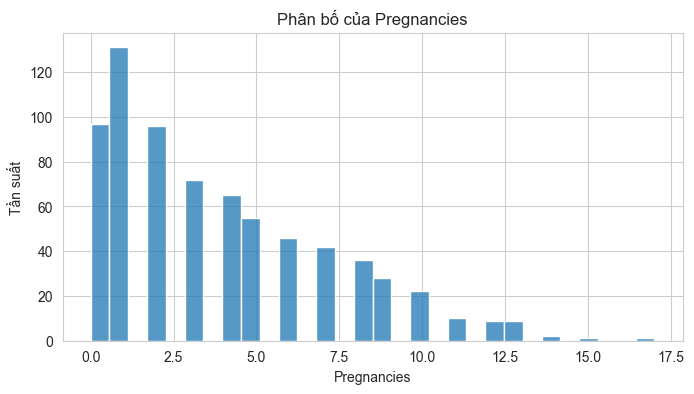

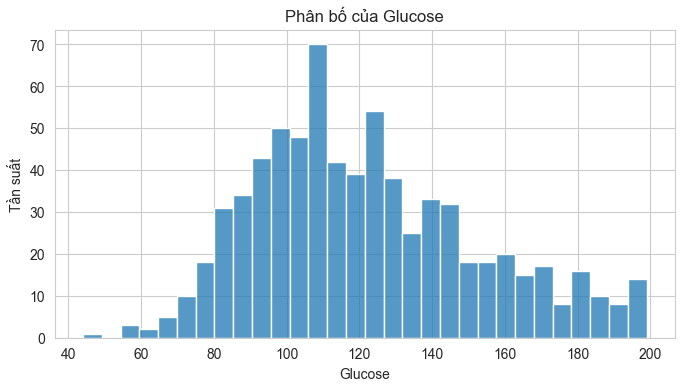

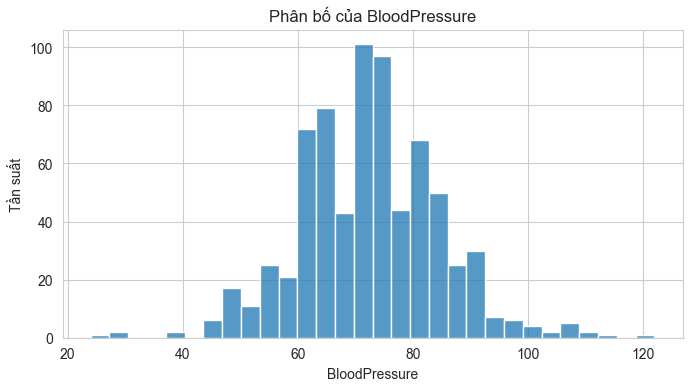

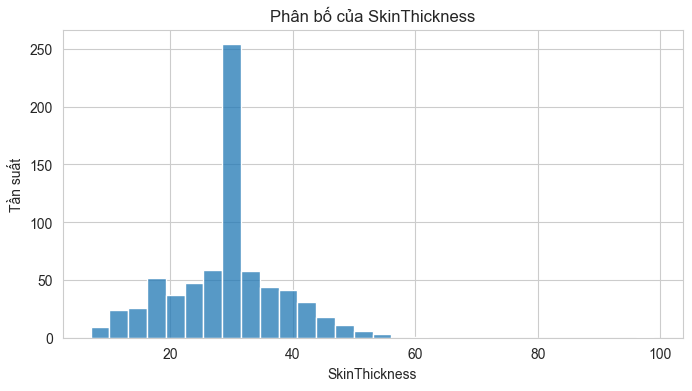

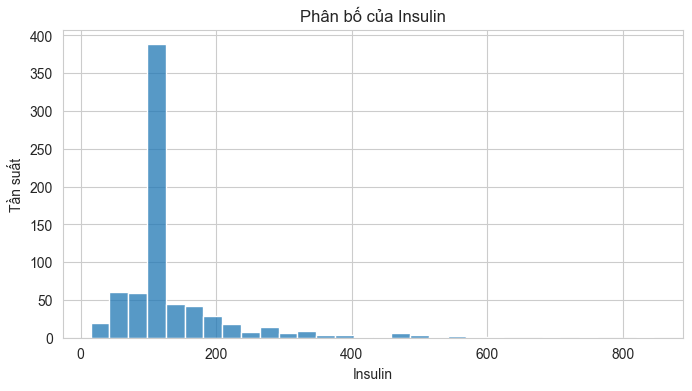

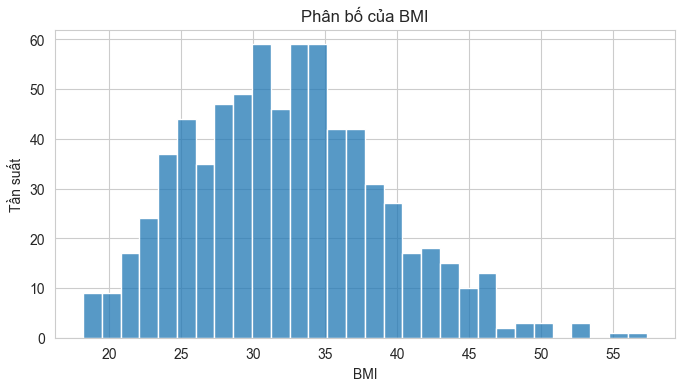

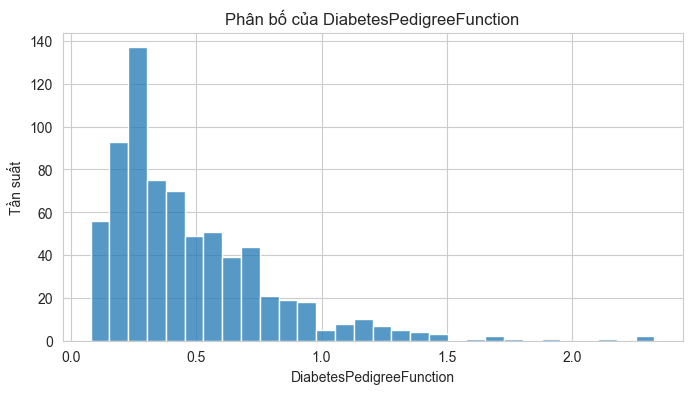

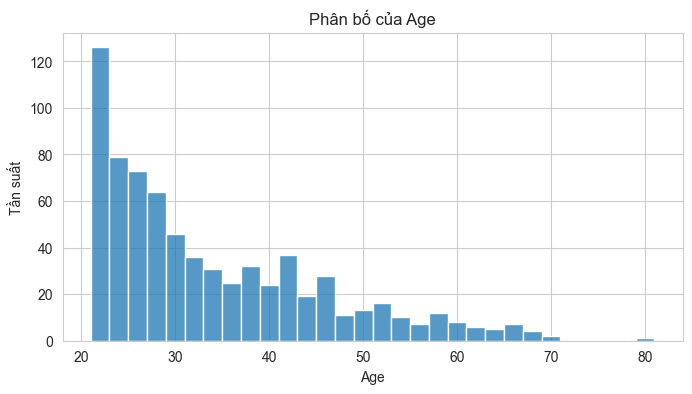

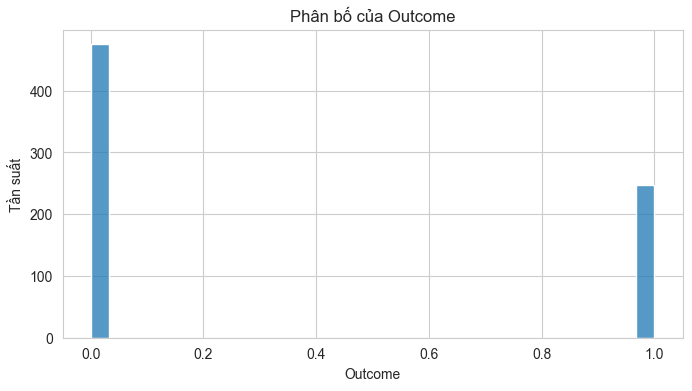

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in df_final.columns:
    plt.figure(figsize=(8,4))
    
    if df_final[column].dtype in ['int64', 'float64']:
        sns.histplot(data=df_final, x=column, bins=30)
        plt.ylabel("Tần suất")

    else:
        sns.countplot(data=df_final, x=column)
        plt.ylabel("Số lượng")
    
    plt.title(f"Phân bố của {column}")
    plt.xlabel(column)
    plt.show()

=== PHÁT HIỆN OUTLIERS BẰNG IQR ===
Pregnancies: 4 outliers
  - Giới hạn dưới: -6.50, Giới hạn trên: 13.50
  - Giá trị outliers: [np.int64(14), np.int64(15), np.int64(17)]...

Glucose: 0 outliers

BloodPressure: 13 outliers
  - Giới hạn dưới: 40.00, Giới hạn trên: 104.00
  - Giá trị outliers: [np.int64(24), np.int64(30), np.int64(38), np.int64(106), np.int64(108), np.int64(110), np.int64(114), np.int64(122)]...

SkinThickness: 51 outliers
  - Giới hạn dưới: 13.00, Giới hạn trên: 45.00
  - Giá trị outliers: [np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]...

Insulin: 303 outliers
  - Giới hạn dưới: 100.88, Giới hạn trên: 149.88
  - Giá trị outliers: [np.int64(15), np.int64(16), np.int64(18), np.int64(22), np.int64(23), np.int64(25), np.int64(29), np.int64(32), np.int64(36), np.int64(37)]...

BMI: 5 outliers
  - Giới hạn dưới: 13.85, Giới hạn trên: 50.25
  - Giá trị outliers: [np.float64(52.3), np.

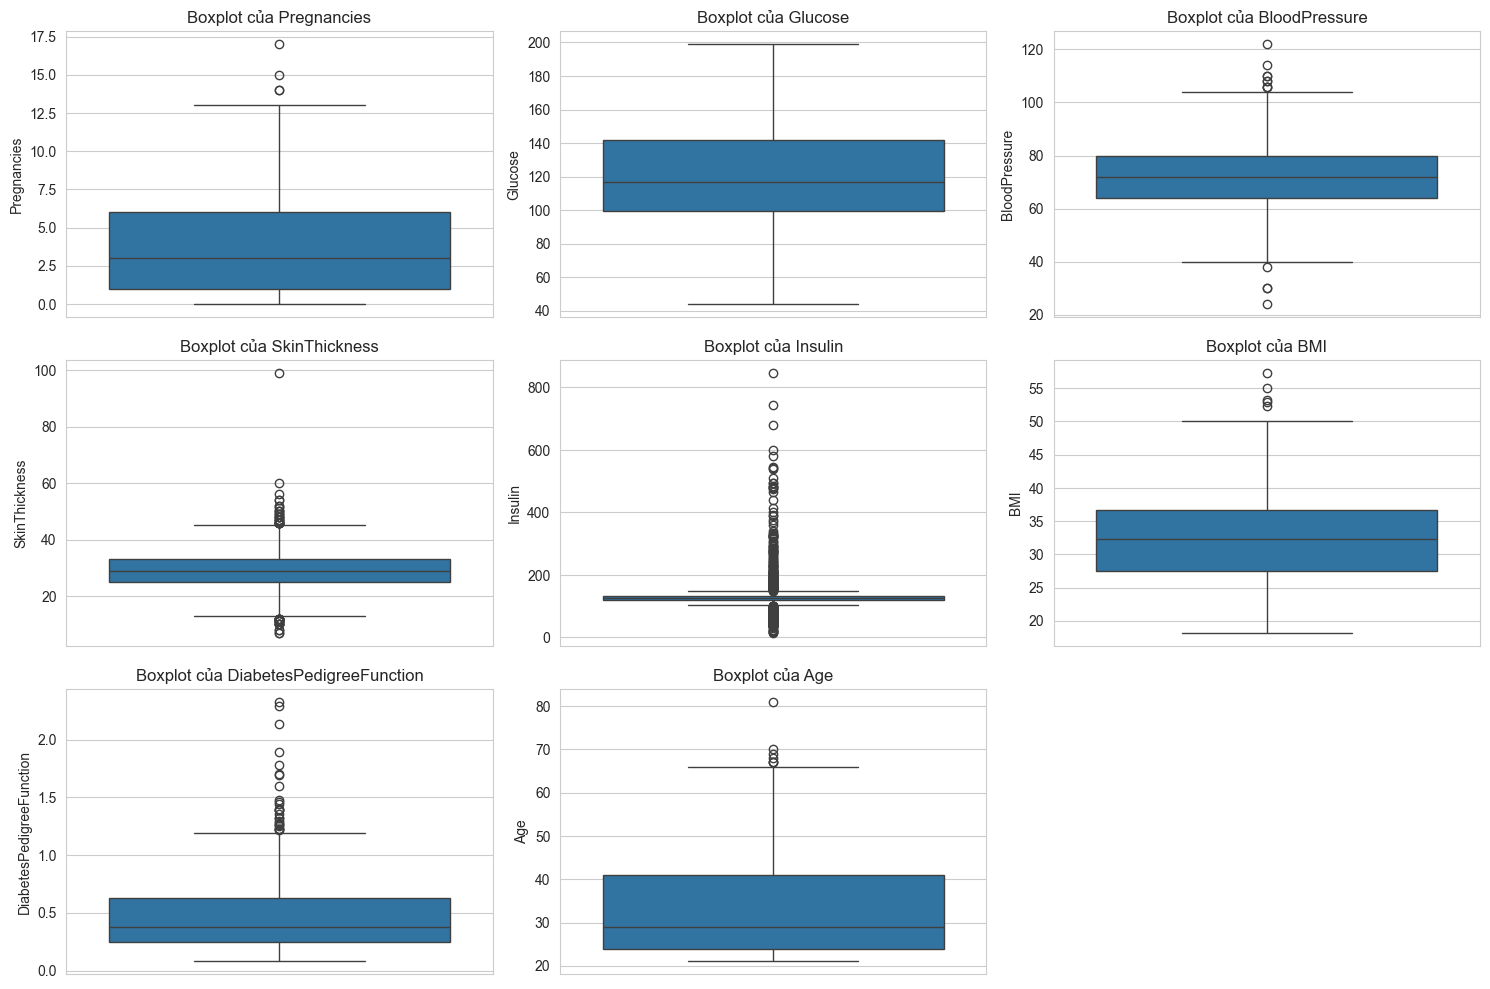

In [60]:
import numpy as np
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound
print("=== PHÁT HIỆN OUTLIERS BẰNG IQR ===")
numeric_columns = df_final.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if col != 'Outcome':  
        outliers, lower, upper = detect_outliers_iqr(df_final, col)
        print(f"{col}: {len(outliers)} outliers")
        if len(outliers) > 0:
            print(f"  - Giới hạn dưới: {lower:.2f}, Giới hạn trên: {upper:.2f}")
            print(f"  - Giá trị outliers: {sorted(outliers[col].unique())[:10]}...")  
        print()
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    if col != 'Outcome':
        plt.subplot(3, 3, i+1)
        sns.boxplot(y=df_final[col])
        plt.title(f'Boxplot của {col}')
plt.tight_layout()
plt.show()

### Phân tích biến mục tiêu

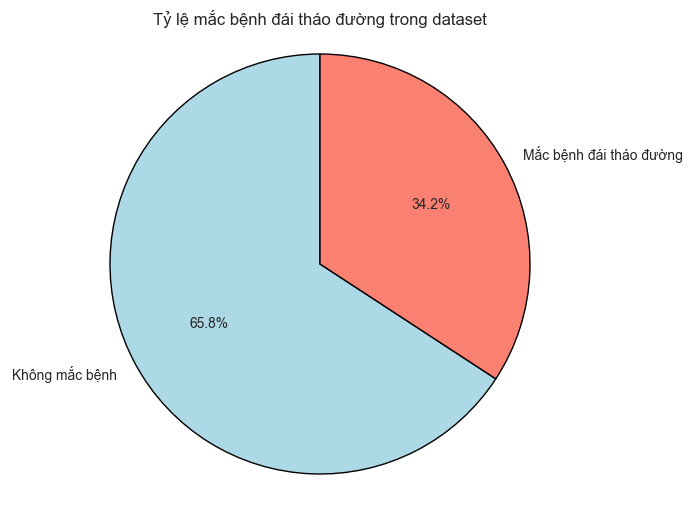

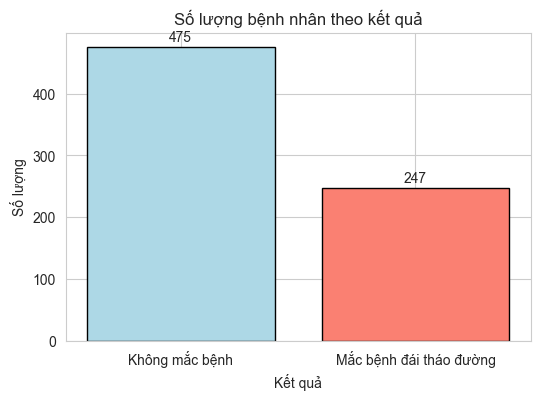

In [61]:
outcome_counts = df_final['Outcome'].value_counts()
labels = ['Không mắc bệnh', 'Mắc bệnh đái tháo đường']
colors = ['lightblue', 'salmon']
plt.figure(figsize=(8, 6))
plt.pie(outcome_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Tỷ lệ mắc bệnh đái tháo đường trong dataset')
plt.axis('equal') 
plt.show()
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, outcome_counts.values, color=colors, edgecolor='black')
plt.title('Số lượng bệnh nhân theo kết quả')
plt.ylabel('Số lượng')
plt.xlabel('Kết quả')
for bar, count in zip(bars, outcome_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', va='bottom')
plt.show()

### Đặc điểm nhóm bệnh nhân và nhóm khỏe mạnh

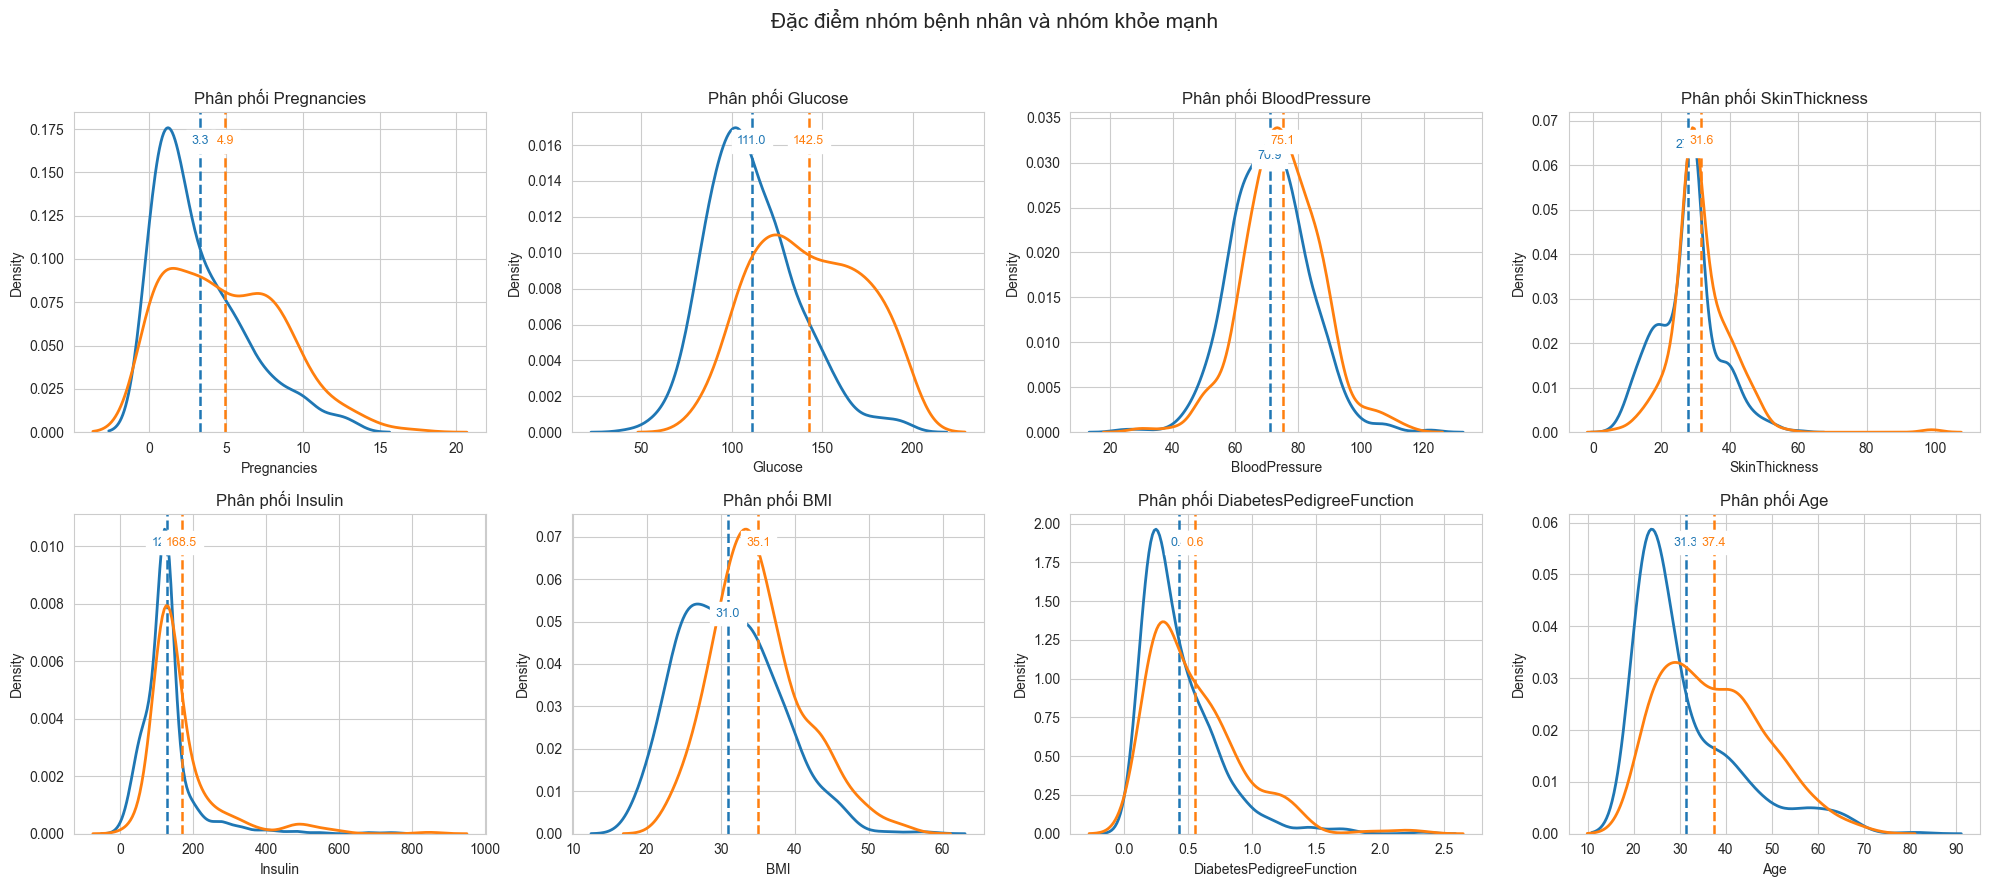

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()
df_plot['Group'] = df_plot['Outcome'].map({0: 'Không mắc', 1: 'Mắc'})

features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

sns.set_style("whitegrid")

fig, axes = plt.subplots(2,4, figsize=(20,9))
axes = axes.flatten()
colors = ['#1f77b4', '#ff7f0e']

for i, col in enumerate(features):
    ax = axes[i]

    for group, color in zip(['Không mắc', 'Mắc'], colors):

        subset = df_plot[df_plot['Group'] == group]

        sns.kdeplot(
            data=subset,
            x=col,
            linewidth=2,
            color=color,
            ax=ax
        )

        mean_val = subset[col].mean()
        ax.axvline(mean_val,
                   color=color,
                   linestyle='--',
                   linewidth=1.8)

        ax.text(mean_val,
                ax.get_ylim()[1]*0.9,
                f"{mean_val:.1f}",
                color=color,
                fontsize=9,
                ha='center',
                backgroundcolor='white')

    ax.set_title(f'Phân phối {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.suptitle('Đặc điểm nhóm bệnh nhân và nhóm khỏe mạnh', fontsize=15)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

### Biểu đồ phân bố bệnh theo độ tuổi

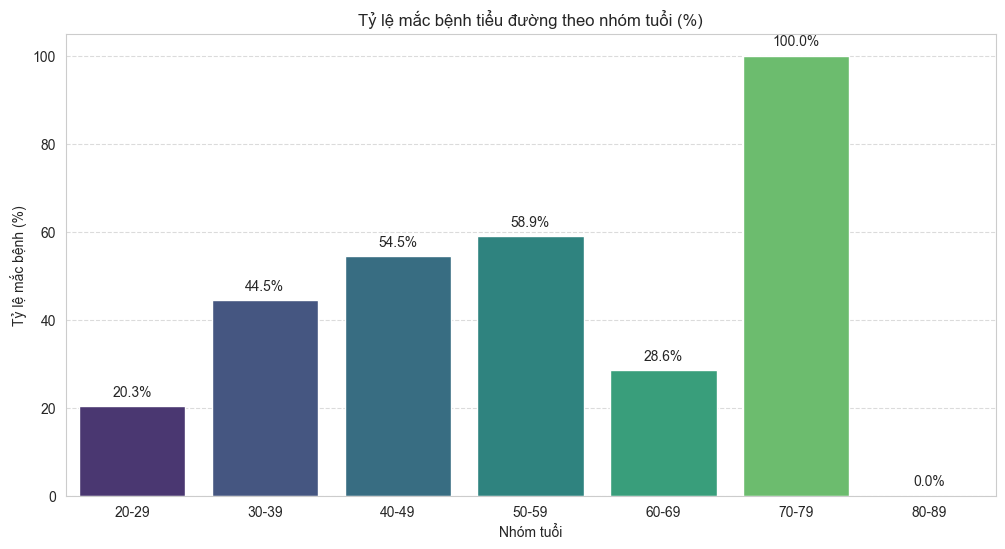

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df_plot = df_final.copy()

bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']

df_plot['Age_Group'] = pd.cut(df_plot['Age'], bins=bins, labels=labels, right=False)

age_disease_rate = df_plot.groupby('Age_Group')['Outcome'].mean().reset_index()
age_disease_rate['Outcome'] *= 100

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=age_disease_rate,
    x='Age_Group',
    y='Outcome',
    palette='viridis'
)

plt.title('Tỷ lệ mắc bệnh tiểu đường theo nhóm tuổi (%)')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Tỷ lệ mắc bệnh (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0,5),
                textcoords='offset points')

plt.show()

### Các chỉ số sinh lí thay đổi theo tuổi

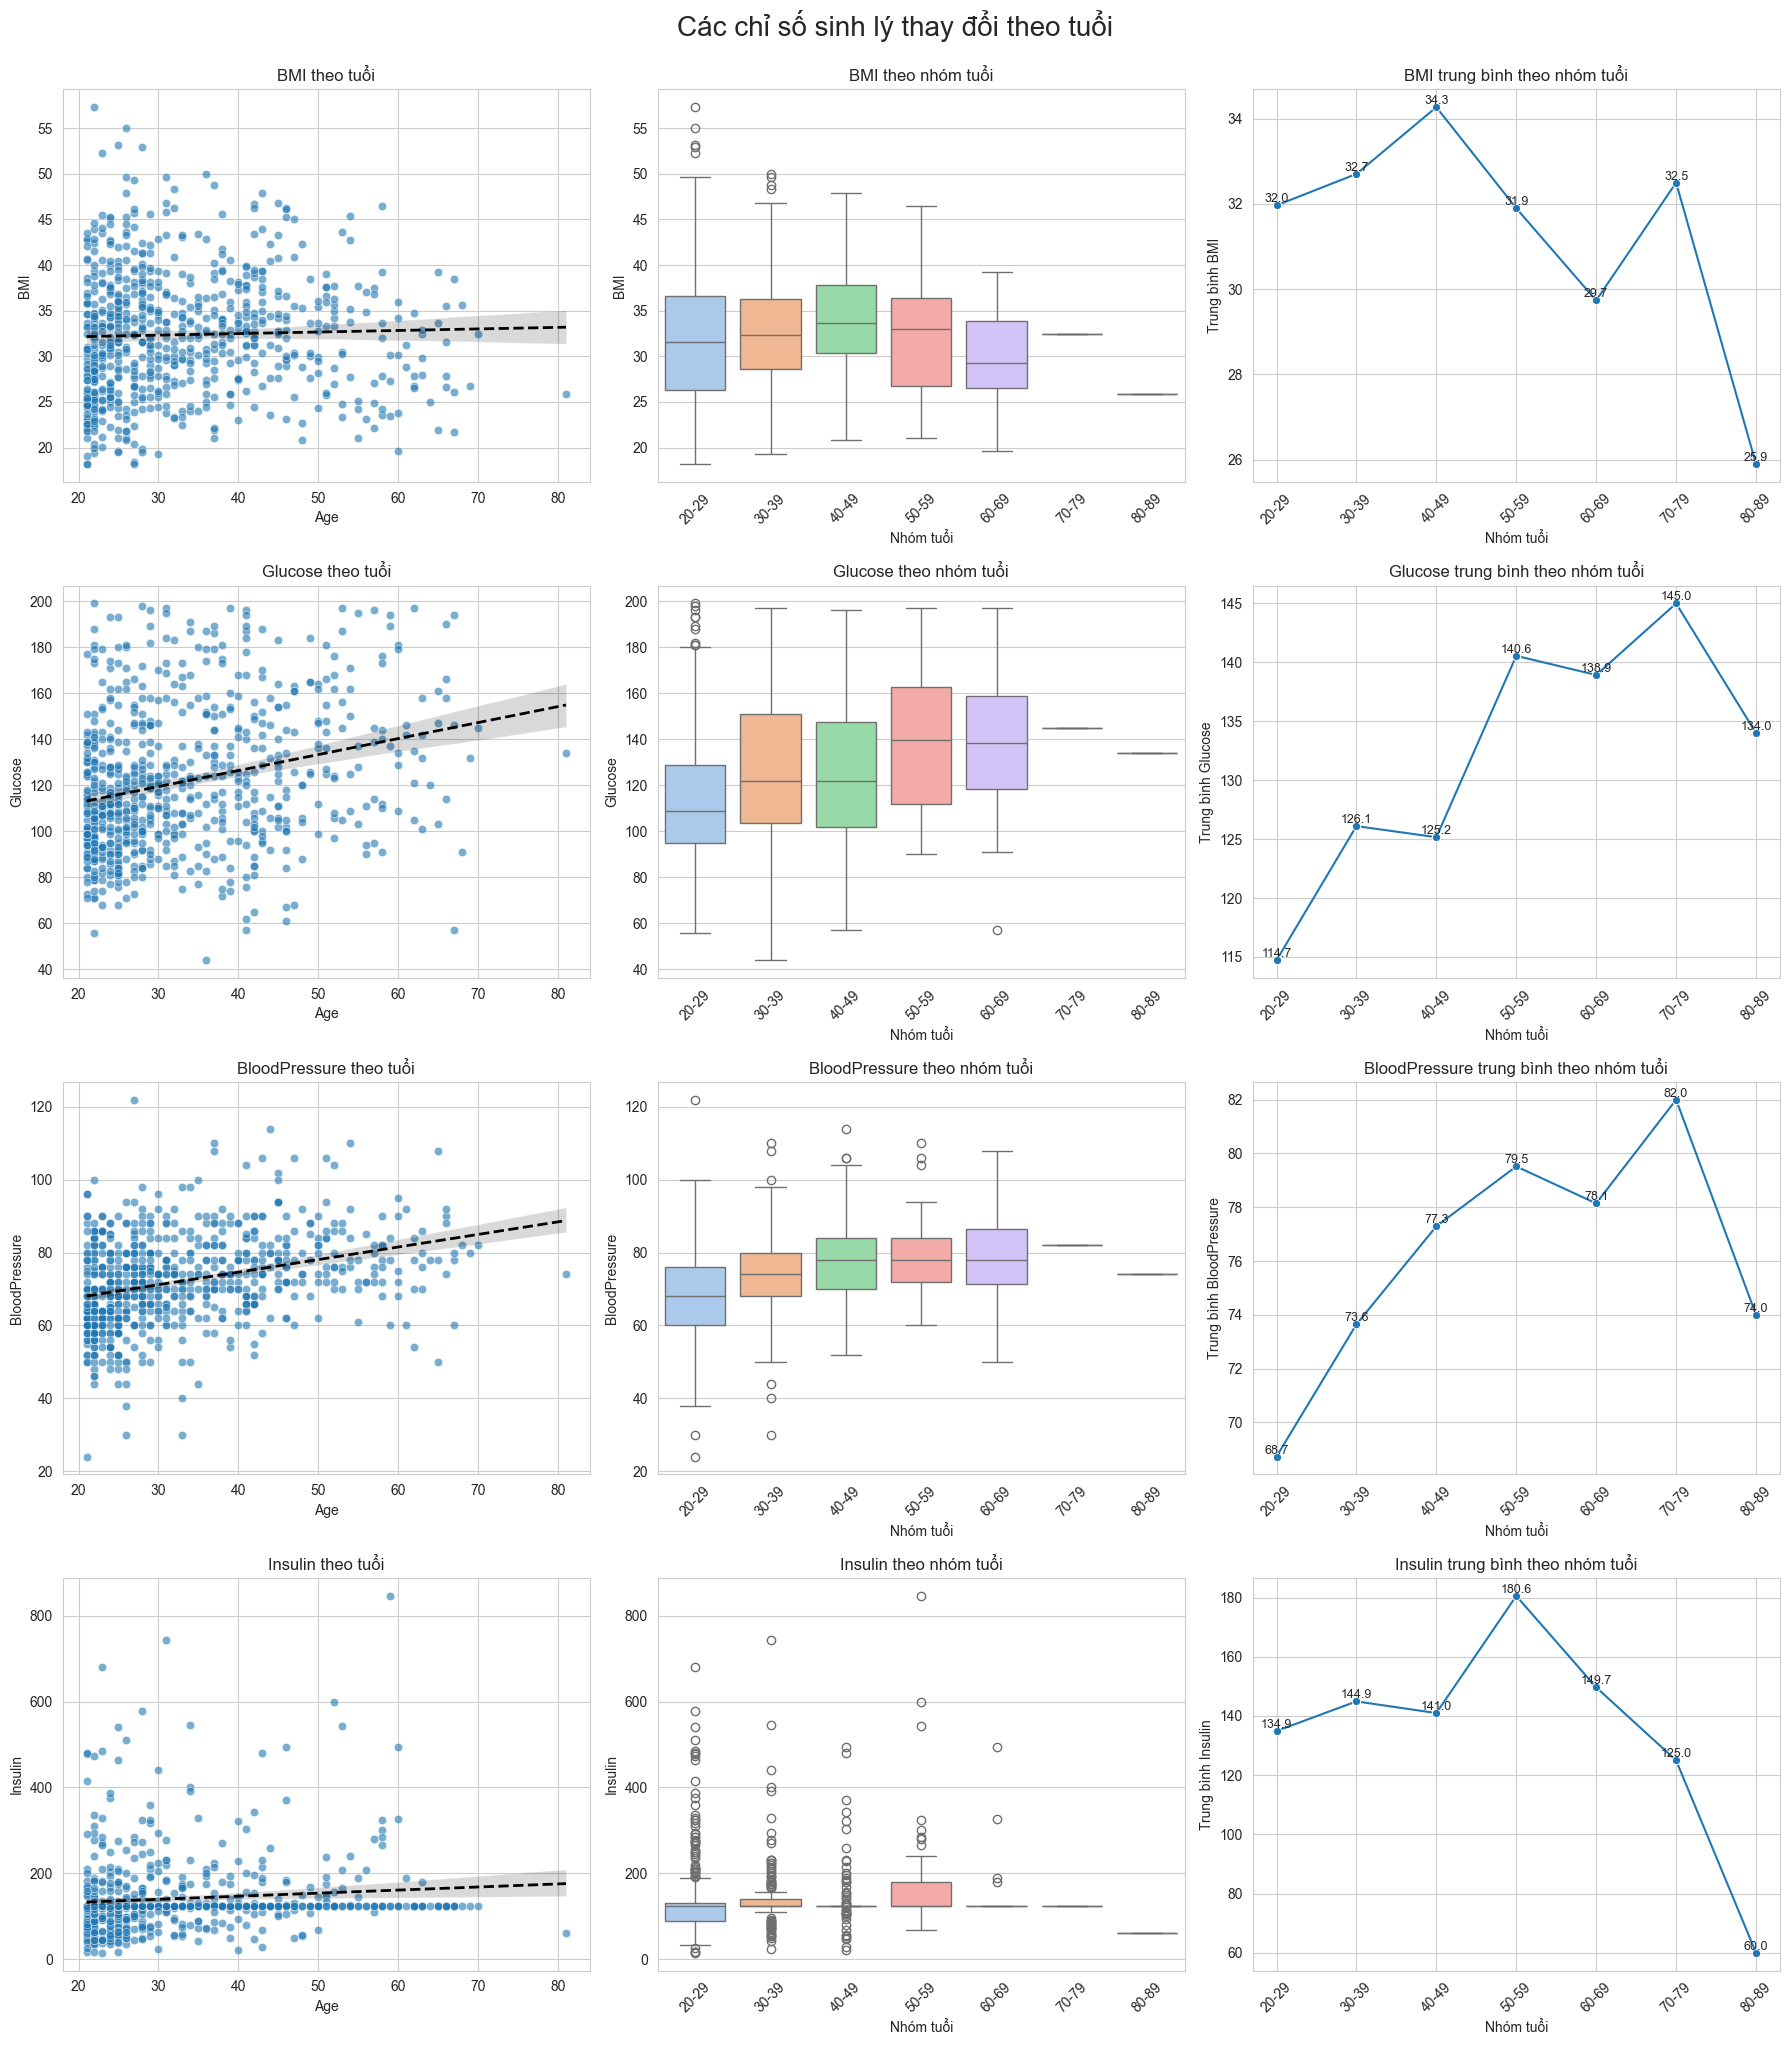

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_plot = df_final.copy()

bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']

df_plot['Age_Group'] = pd.cut(df_plot['Age'], bins=bins, labels=labels, right=False)

features = ['BMI', 'Glucose', 'BloodPressure', 'Insulin']

sns.set_style('whitegrid')
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feat in enumerate(features):

  
    ax = axes[i*3]
    sns.scatterplot(data=df_plot, x='Age', y=feat, alpha=0.6, ax=ax)
    sns.regplot(data=df_plot, x='Age', y=feat, scatter=False,
                line_kws={'color':'black','lw':2,'ls':'--'}, ax=ax)

    ax.set_title(f'{feat} theo tuổi')
    ax.set_xlabel('Age')
    ax.set_ylabel(feat)

    ax = axes[i*3 + 1]
    sns.boxplot(data=df_plot, x='Age_Group', y=feat, palette='pastel', ax=ax)

    ax.set_title(f'{feat} theo nhóm tuổi')
    ax.set_xlabel('Nhóm tuổi')
    ax.set_ylabel(feat)
    ax.tick_params(axis='x', rotation=45)

  
    avg = df_plot.groupby('Age_Group')[feat].mean().reset_index()

    ax = axes[i*3 + 2]
    sns.lineplot(data=avg, x='Age_Group', y=feat, marker='o', ax=ax)

    ax.set_title(f'{feat} trung bình theo nhóm tuổi')
    ax.set_xlabel('Nhóm tuổi')
    ax.set_ylabel(f'Trung bình {feat}')
    ax.tick_params(axis='x', rotation=45)

    for x, y in zip(avg['Age_Group'], avg[feat]):
        ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Các chỉ số sinh lý thay đổi theo tuổi', fontsize=20, y=1.02)
plt.show()

### Biểu đồ tỉ lệ mắc bệnh ở từng nhóm tuổi

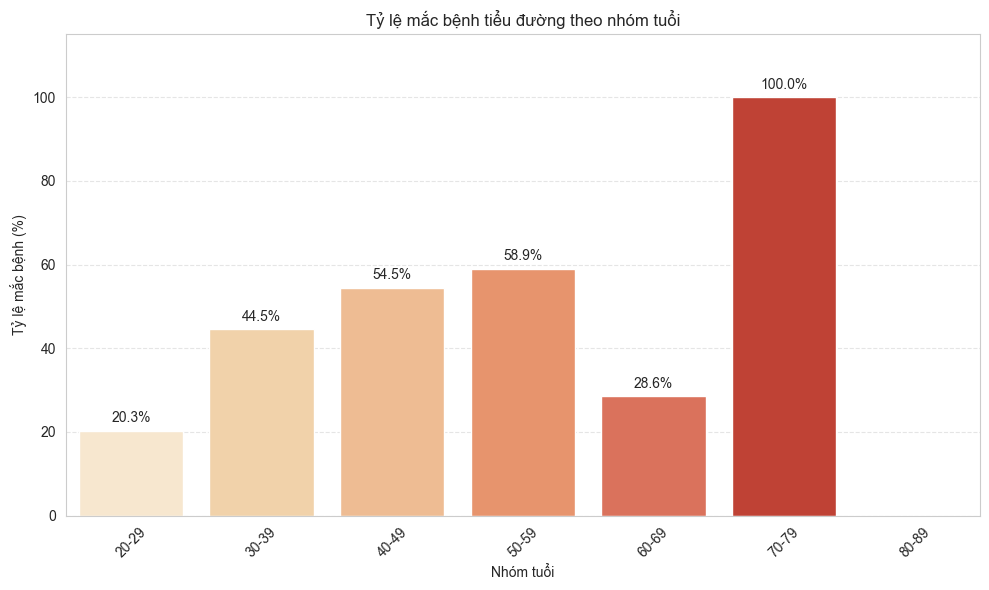

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_plot = df_final.copy()


bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']

df_plot['Age_Group'] = pd.cut(df_plot['Age'], bins=bins, labels=labels, right=False)


age_disease_rate = (
    df_plot.groupby('Age_Group')['Outcome']
    .mean()
    .reset_index(name='Diabetes_Rate')
)

age_disease_rate['Diabetes_Rate'] *= 100

age_disease_rate = age_disease_rate.dropna()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=age_disease_rate,
    x='Age_Group',
    y='Diabetes_Rate',
    palette='OrRd'
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%',
                    (p.get_x() + p.get_width()/2, h),
                    ha='center', va='bottom',
                    xytext=(0,4),
                    textcoords='offset points')

ax.set_title('Tỷ lệ mắc bệnh tiểu đường theo nhóm tuổi')
ax.set_xlabel('Nhóm tuổi')
ax.set_ylabel('Tỷ lệ mắc bệnh (%)')

ax.set_ylim(0, age_disease_rate['Diabetes_Rate'].max()*1.15)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Phân tích tỉ lệ mắc bệnh theo chỉ số BMI

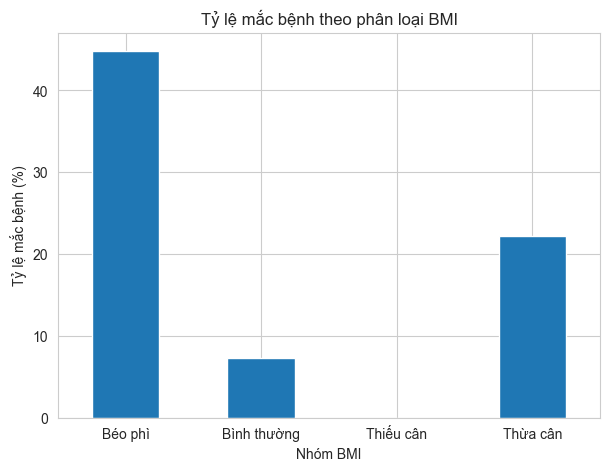

In [66]:
import pandas as pd
import matplotlib.pyplot as plt


def bmi_category(bmi):
    if bmi < 18.5:
        return "Thiếu cân"
    elif bmi < 25:
        return "Bình thường"
    elif bmi < 30:
        return "Thừa cân"
    else:
        return "Béo phì"

df_final['BMI_Category'] = df_final['BMI'].apply(bmi_category)


bmi_outcome = df_final.groupby('BMI_Category')['Outcome'].mean() * 100


plt.figure(figsize=(7,5))
bmi_outcome.plot(kind='bar')

plt.title("Tỷ lệ mắc bệnh theo phân loại BMI")
plt.xlabel("Nhóm BMI")
plt.ylabel("Tỷ lệ mắc bệnh (%)")
plt.xticks(rotation=0)

plt.show()

### Bảng quan hệ giữa béo phì và bệnh tiểu đường

In [67]:
import pandas as pd

column_bmi = 'BMI'
column_outcome = 'Outcome'


df_final = df_final[df_final[column_bmi] > 0]

bins = [0, 18.5, 25, 30, 100]
labels = ['Gầy', 'Bình thường', 'Thừa cân', 'Béo phì']

df_final['Nhóm BMI'] = pd.cut(df_final[column_bmi], bins=bins, labels=labels, right=False)

summary_table = df_final.groupby('Nhóm BMI').agg(
    Tong_so=(column_outcome, 'count'),
    So_ca_mac=(column_outcome, 'sum'),
    BMI_trung_binh=(column_bmi, 'mean')
).reset_index()

summary_table['Tỷ lệ mắc (%)'] = (
    summary_table['So_ca_mac'] / summary_table['Tong_so'] * 100
).round(1).astype(str) + '%'

summary_table['BMI_trung_binh'] = summary_table['BMI_trung_binh'].round(1)

summary_table = summary_table[['Nhóm BMI','Tong_so','So_ca_mac','Tỷ lệ mắc (%)','BMI_trung_binh']]

summary_table.columns = ['Nhóm BMI', 'Tổng số', 'Số ca mắc', 'Tỷ lệ mắc (%)', 'BMI trung bình']

print(summary_table)

      Nhóm BMI  Tổng số  Số ca mắc Tỷ lệ mắc (%)  BMI trung bình
0          Gầy        4          0          0.0%            18.2
1  Bình thường       96          7          7.3%            22.8
2     Thừa cân      171         38         22.2%            27.5
3      Béo phì      451        202         44.8%            36.4


### BMI kết hợp với các yếu tố khác

### BMI và Glucose

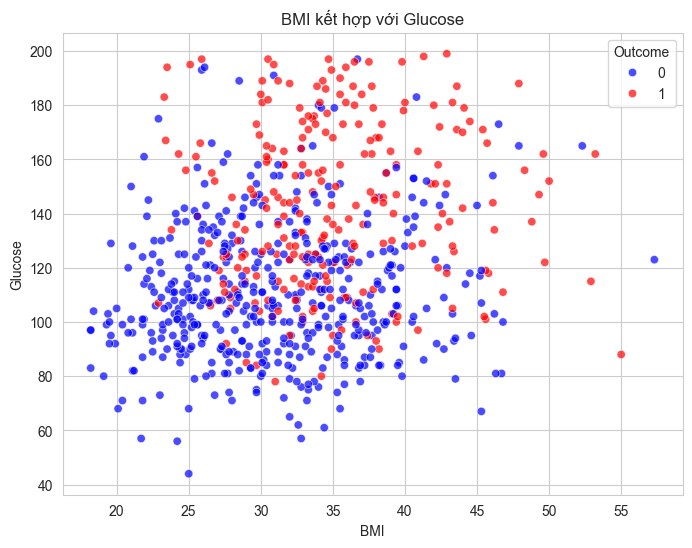

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_plot,
    x='BMI',
    y='Glucose',
    hue='Outcome',
    palette=['blue','red'],
    alpha=0.7
)

plt.title("BMI kết hợp với Glucose")
plt.xlabel("BMI")
plt.ylabel("Glucose")

plt.show()

### BMI và tuổi

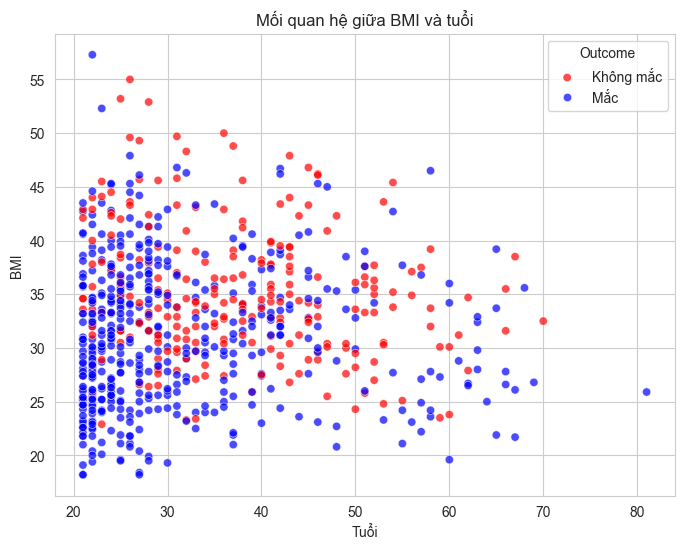

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_plot,
    x='Age',
    y='BMI',
    hue='Outcome',
    palette=['blue','red'],
    alpha=0.7
)

plt.title("Mối quan hệ giữa BMI và tuổi")
plt.xlabel("Tuổi")
plt.ylabel("BMI")
plt.legend(title="Outcome", labels=["Không mắc", "Mắc"])

plt.show()

### BMI và Insulin

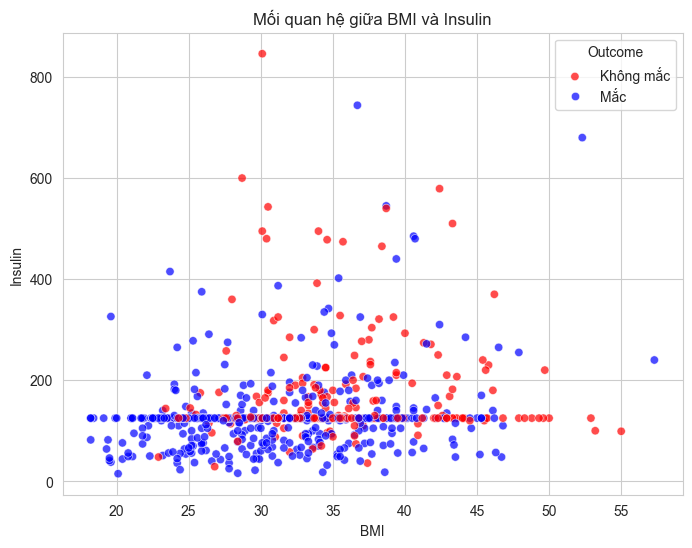

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_plot,
    x='BMI',
    y='Insulin',
    hue='Outcome',
    palette=['blue','red'],
    alpha=0.7
)

plt.title("Mối quan hệ giữa BMI và Insulin")
plt.xlabel("BMI")
plt.ylabel("Insulin")
plt.legend(title="Outcome", labels=["Không mắc", "Mắc"])

plt.show()

### Phân bố bệnh theo nồng độ Glucose

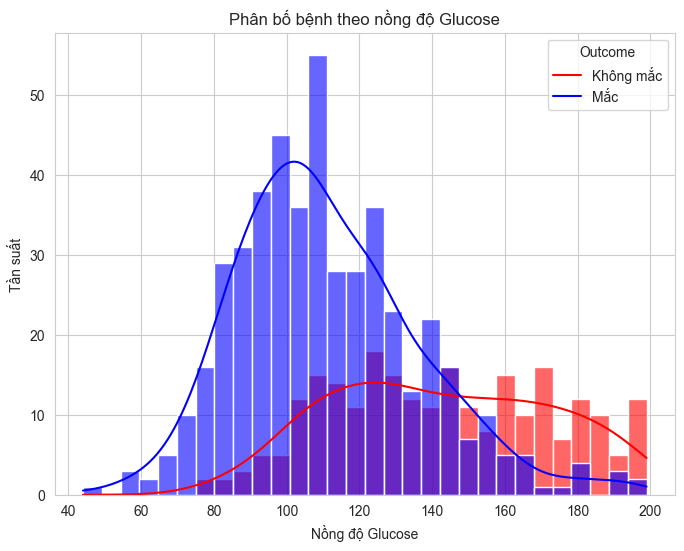

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()

plt.figure(figsize=(8,6))

sns.histplot(
    data=df_plot,
    x='Glucose',
    hue='Outcome',
    bins=30,
    kde=True,
    palette=['blue','red'],
    alpha=0.6
)

plt.title("Phân bố bệnh theo nồng độ Glucose")
plt.xlabel("Nồng độ Glucose")
plt.ylabel("Tần suất")

plt.legend(title="Outcome", labels=["Không mắc", "Mắc"])

plt.show()

### Mối quan hệ giữa Glucose và Insulin

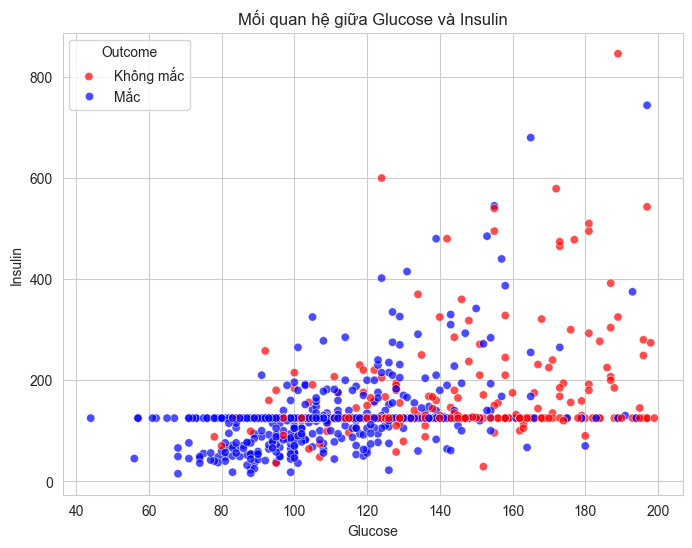

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_plot,
    x='Glucose',
    y='Insulin',
    hue='Outcome',
    palette=['blue','red'],
    alpha=0.7
)

plt.title("Mối quan hệ giữa Glucose và Insulin")
plt.xlabel("Glucose")
plt.ylabel("Insulin")
plt.legend(title="Outcome", labels=["Không mắc", "Mắc"])

plt.show()

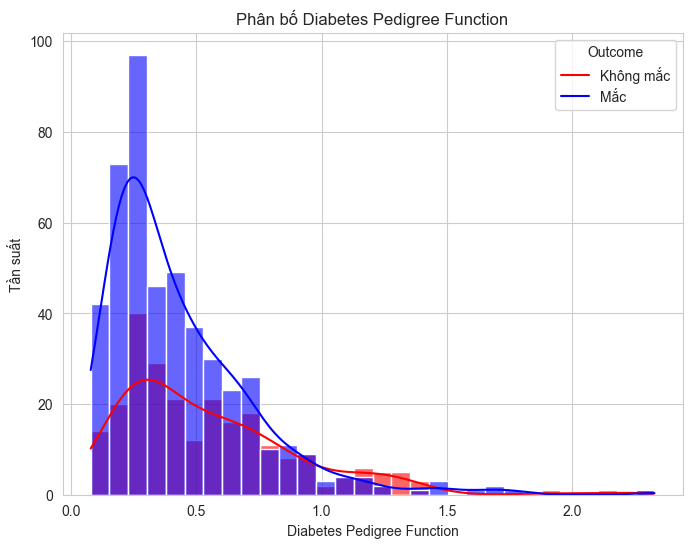

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()

plt.figure(figsize=(8,6))

sns.histplot(
    data=df_plot,
    x='DiabetesPedigreeFunction',
    hue='Outcome',
    bins=30,
    kde=True,
    palette=['blue','red'],
    alpha=0.6
)

plt.title("Phân bố Diabetes Pedigree Function")
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Tần suất")

plt.legend(title="Outcome", labels=["Không mắc", "Mắc"])

plt.show()

### Tác động của di truyền

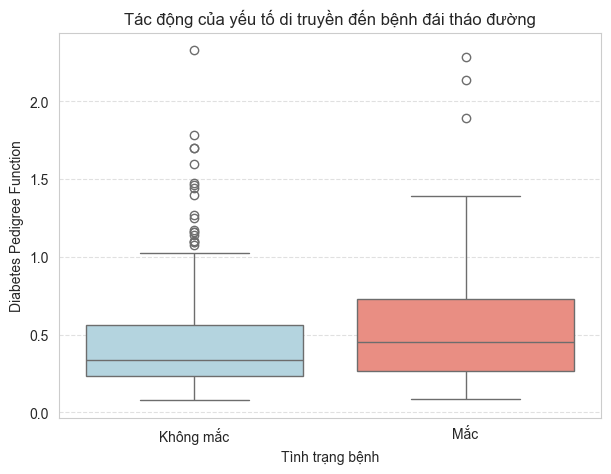

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_plot,
    x='Outcome',
    y='DiabetesPedigreeFunction',
    palette=['lightblue','salmon']
)

plt.xticks([0,1], ["Không mắc", "Mắc"])

plt.title("Tác động của yếu tố di truyền đến bệnh đái tháo đường")
plt.xlabel("Tình trạng bệnh")
plt.ylabel("Diabetes Pedigree Function")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

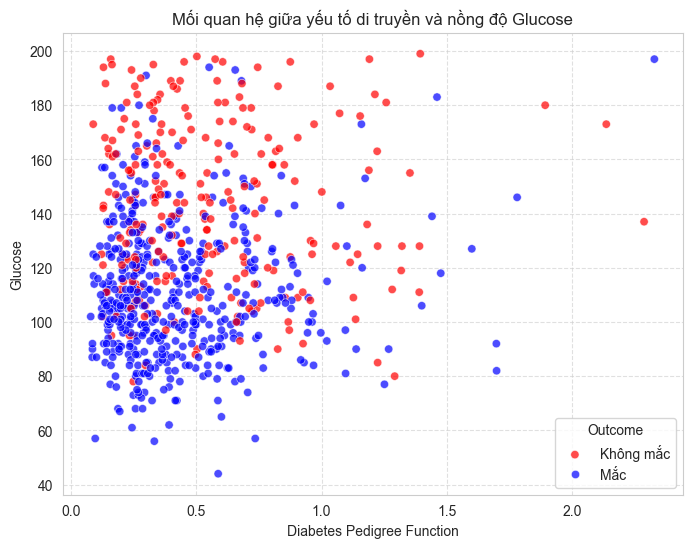

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_plot,
    x='DiabetesPedigreeFunction',
    y='Glucose',
    hue='Outcome',
    palette=['blue','red'],
    alpha=0.7
)

plt.title("Mối quan hệ giữa yếu tố di truyền và nồng độ Glucose")
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Glucose")

plt.legend(title="Outcome", labels=["Không mắc", "Mắc"])

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Phân tích theo số lần có thai

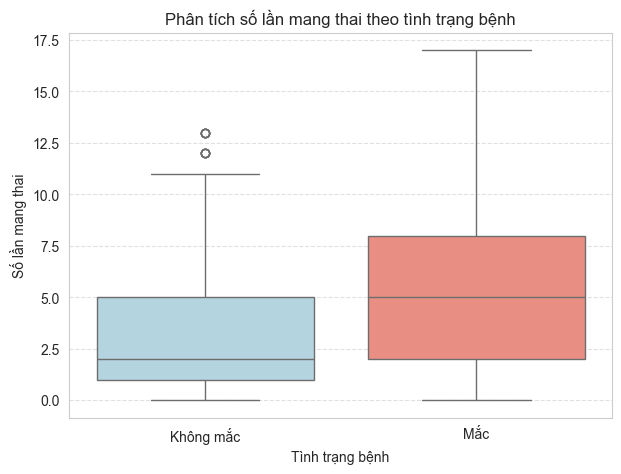

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_plot,
    x='Outcome',
    y='Pregnancies',
    palette=['lightblue','salmon']
)

plt.xticks([0,1], ["Không mắc", "Mắc"])

plt.title("Phân tích số lần mang thai theo tình trạng bệnh")
plt.xlabel("Tình trạng bệnh")
plt.ylabel("Số lần mang thai")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

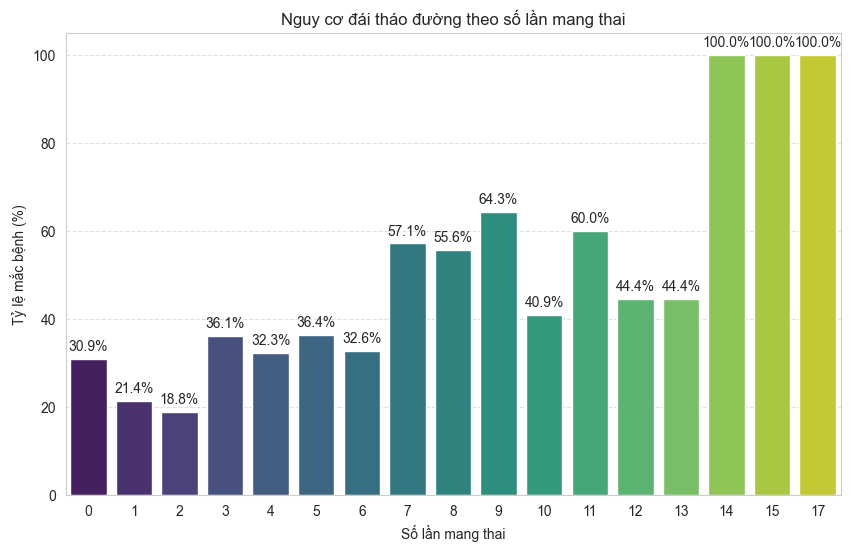

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_plot = df_final.copy()
pregnancy_risk = (
    df_plot.groupby('Pregnancies')['Outcome']
    .mean()
    .reset_index(name='Diabetes_Rate')
)
pregnancy_risk['Diabetes_Rate'] *= 100
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=pregnancy_risk,
    x='Pregnancies',
    y='Diabetes_Rate',
    palette='viridis'
)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom',
                    xytext=(0,4),
                    textcoords='offset points')
plt.title("Nguy cơ đái tháo đường theo số lần mang thai")
plt.xlabel("Số lần mang thai")
plt.ylabel("Tỷ lệ mắc bệnh (%)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Ma trận tương quan

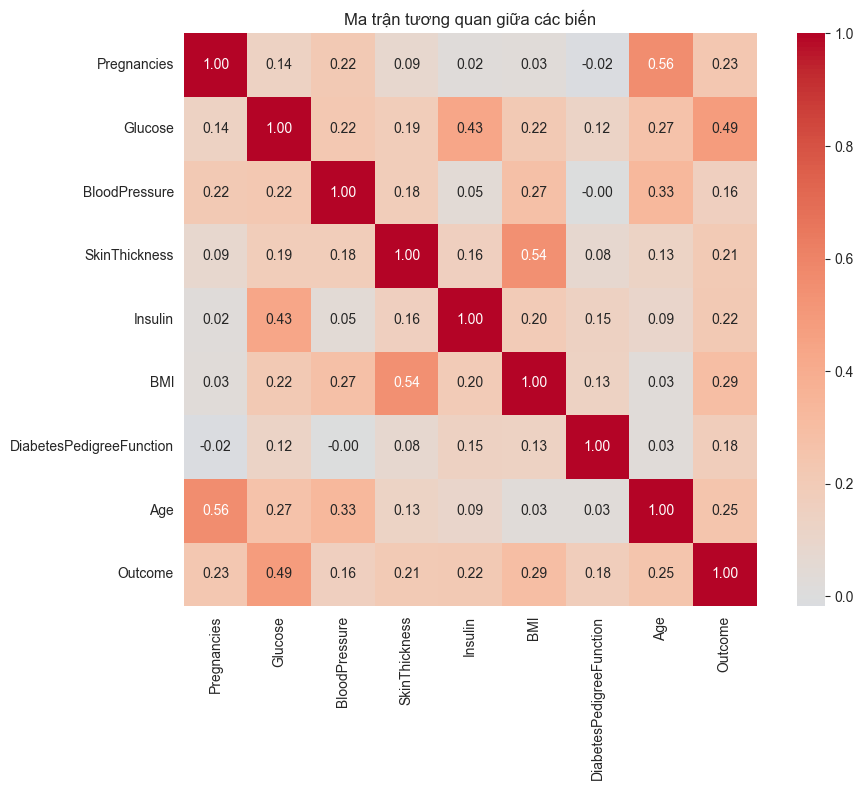

In [78]:
# 5.1 Ma trận tương quan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.figure(figsize=(10, 8))
corr = df_final.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Ma trận tương quan giữa các biến")
plt.tight_layout()
plt.show()

### Phân tích cặp biến quan trọng

In [79]:
# 5.2 Phân tích cặp biến quan trọng

def prop_positive_above_threshold(df_final, col, thresholds, target='Outcome'):
    vals = []
    for thr in thresholds:
        sub = df_final[df_final[col] >= thr]
        if len(sub) == 0:
            vals.append(0)
        else:
            vals.append(round((sub[target].mean() * 100), 1))
    return vals

def make_interval_labels(series, bins=5):
    cat = pd.cut(series, bins=bins)
    return cat

5.2.1. Glucose - Kết quả bệnh
Hệ số tương quan Pearson: 0.49


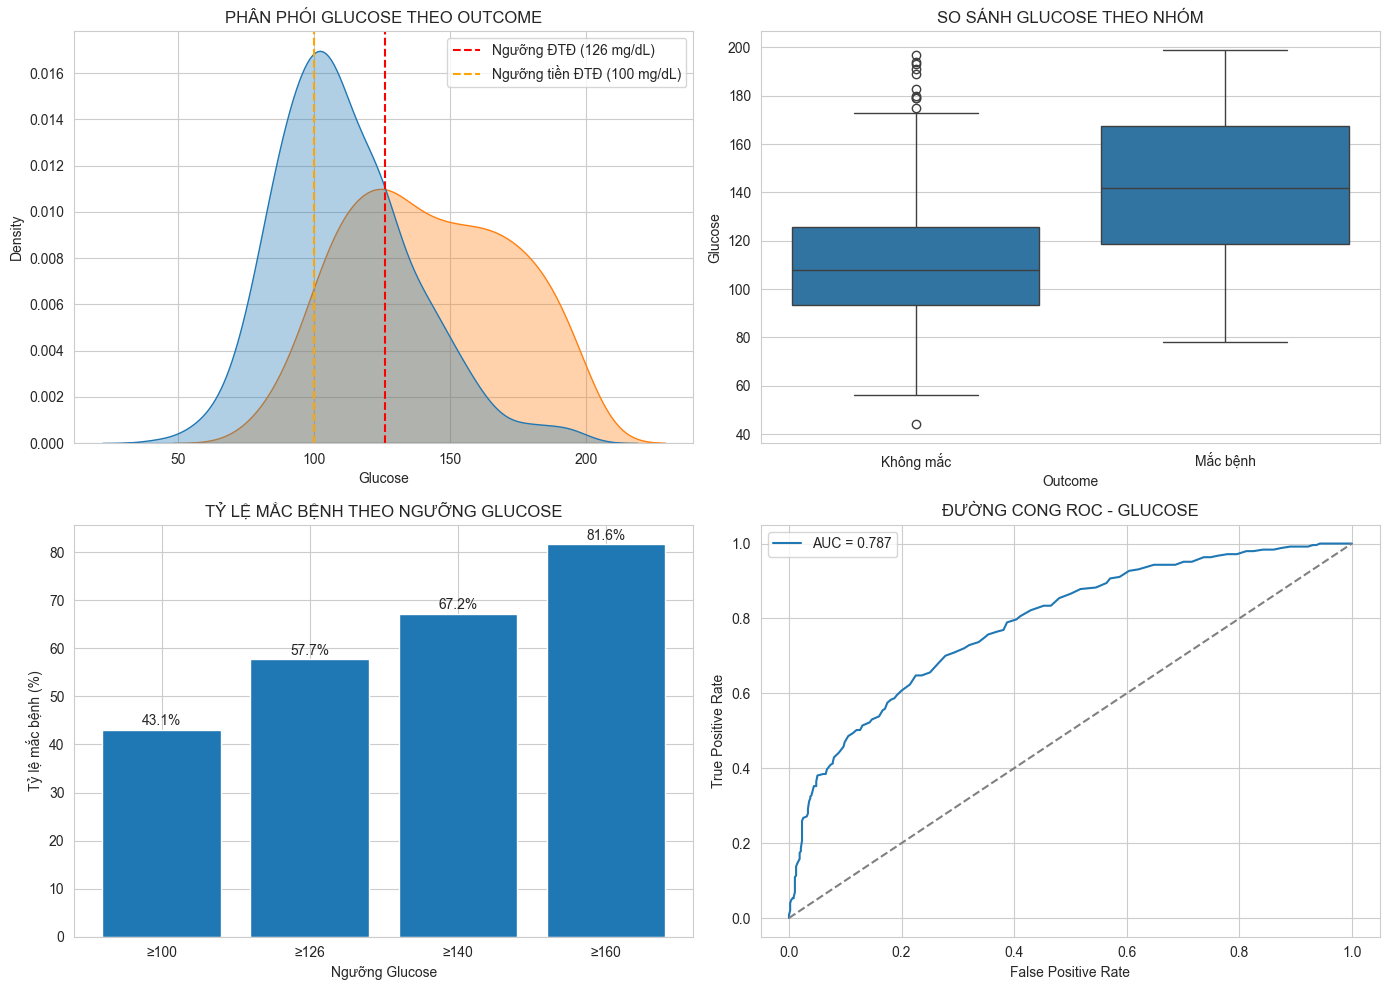

In [80]:
# 5.2.1. Glucose - Kết quả bệnh

corr_glucose_outcome = df_final[['Glucose', 'Outcome']].corr().iloc[0, 1]
print("5.2.1. Glucose - Kết quả bệnh")
print(f"Hệ số tương quan Pearson: {corr_glucose_outcome:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Phân phối Glucose theo Outcome
sns.kdeplot(
    data=df_final, x='Glucose', hue='Outcome',
    fill=True, common_norm=False, alpha=0.35, ax=axes[0, 0]
)
axes[0, 0].axvline(126, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng ĐTĐ (126 mg/dL)')
axes[0, 0].axvline(100, color='orange', linestyle='--', linewidth=1.5, label='Ngưỡng tiền ĐTĐ (100 mg/dL)')
axes[0, 0].set_title('PHÂN PHỐI GLUCOSE THEO OUTCOME')
axes[0, 0].set_xlabel('Glucose')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# 2) Boxplot so sánh Glucose theo nhóm
sns.boxplot(data=df_final, x='Outcome', y='Glucose', order=[0, 1], ax=axes[0, 1])
axes[0, 1].set_title('SO SÁNH GLUCOSE THEO NHÓM')
axes[0, 1].set_xlabel('Outcome')
axes[0, 1].set_ylabel('Glucose')
axes[0, 1].set_xticklabels(['Không mắc', 'Mắc bệnh'])

# 3) Tỷ lệ mắc bệnh theo ngưỡng Glucose
thresholds = [100, 126, 140, 160]
rate_values = prop_positive_above_threshold(df_final, 'Glucose', thresholds)
bar_labels = ['≥100', '≥126', '≥140', '≥160']

axes[1, 0].bar(bar_labels, rate_values)
axes[1, 0].set_title('TỶ LỆ MẮC BỆNH THEO NGƯỠNG GLUCOSE')
axes[1, 0].set_xlabel('Ngưỡng Glucose')
axes[1, 0].set_ylabel('Tỷ lệ mắc bệnh (%)')
for i, v in enumerate(rate_values):
    axes[1, 0].text(i, v + 1, f'{v:.1f}%', ha='center')

# 4) ROC của Glucose
Xg = df_final[['Glucose']].values
y = df_final['Outcome'].values
model_g = LogisticRegression(max_iter=1000)
model_g.fit(Xg, y)
prob_g = model_g.predict_proba(Xg)[:, 1]
fpr_g, tpr_g, _ = roc_curve(y, prob_g)
auc_g = auc(fpr_g, tpr_g)

axes[1, 1].plot(fpr_g, tpr_g, label=f'AUC = {auc_g:.3f}')
axes[1, 1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1, 1].set_title('ĐƯỜNG CONG ROC - GLUCOSE')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend()

plt.tight_layout()
plt.show()




5.2.2. BMI - Độ dày da
Hệ số tương quan Pearson: 0.544


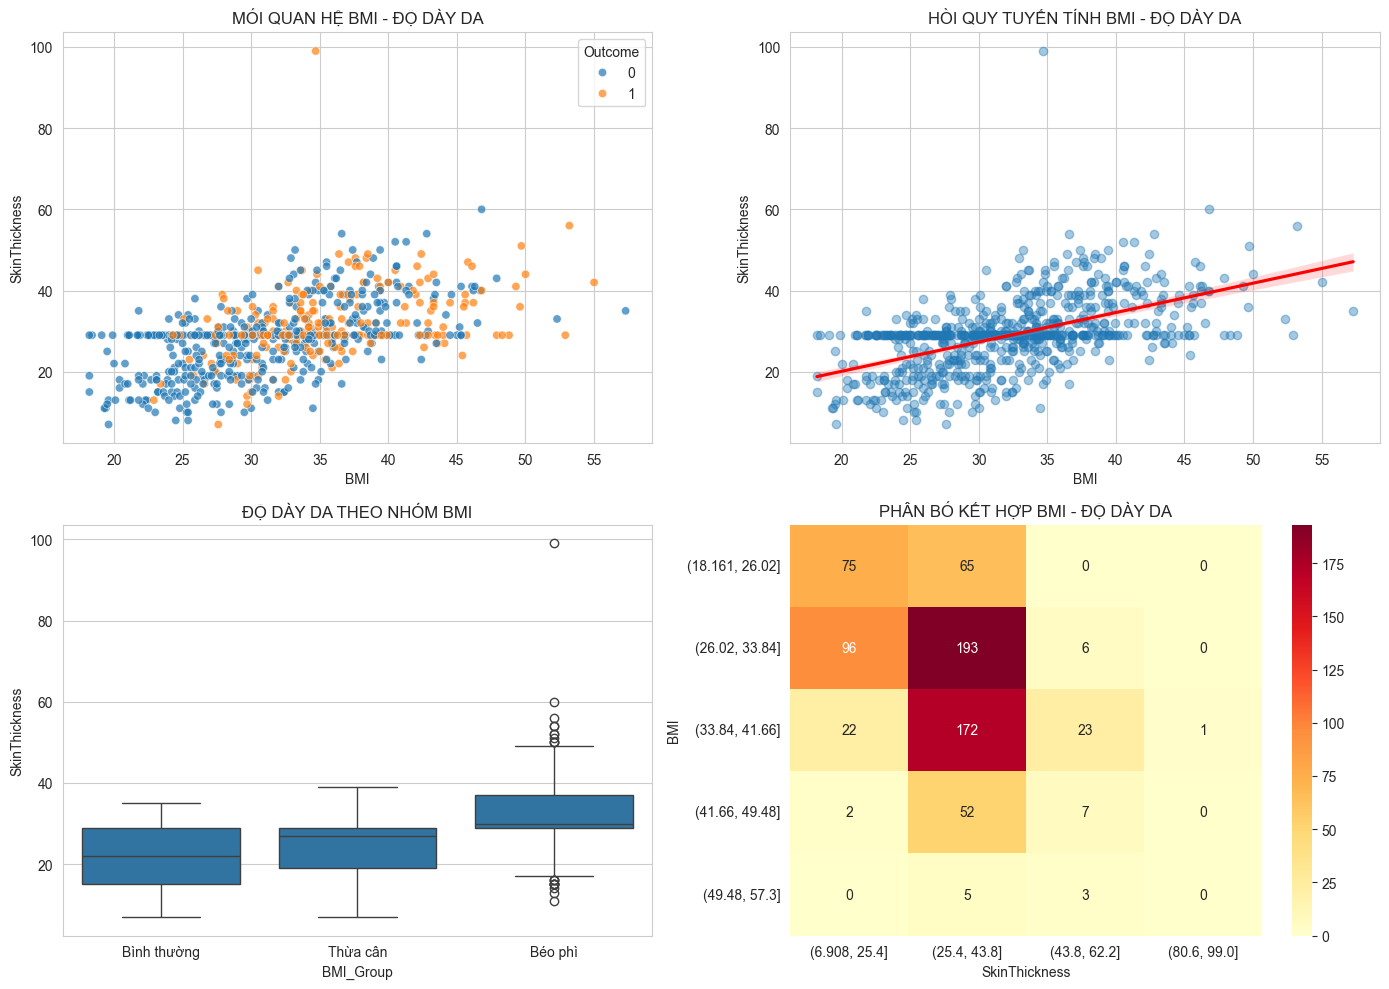

In [81]:
# 5.2.2. BMI - Độ dày da

corr_bmi_skin = df_final[['BMI', 'SkinThickness']].corr().iloc[0, 1]
print("\n5.2.2. BMI - Độ dày da")
print(f"Hệ số tương quan Pearson: {corr_bmi_skin:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Scatter BMI - SkinThickness theo Outcome
sns.scatterplot(data=df_final, x='BMI', y='SkinThickness', hue='Outcome', ax=axes[0, 0], alpha=0.7)
axes[0, 0].set_title('MỐI QUAN HỆ BMI - ĐỘ DÀY DA')
axes[0, 0].set_xlabel('BMI')
axes[0, 0].set_ylabel('SkinThickness')

# 2) Hồi quy tuyến tính BMI - SkinThickness
sns.regplot(data=df_final, x='BMI', y='SkinThickness',
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=axes[0, 1])
axes[0, 1].set_title('HỒI QUY TUYẾN TÍNH BMI - ĐỘ DÀY DA')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('SkinThickness')

# 3) Boxplot SkinThickness theo nhóm BMI
df_final['BMI_Group'] = pd.cut(df_final['BMI'], bins=[0, 25, 30, 100],
                               labels=['Bình thường', 'Thừa cân', 'Béo phì'])
sns.boxplot(data=df_final, x='BMI_Group', y='SkinThickness', ax=axes[1, 0])
axes[1, 0].set_title('ĐỘ DÀY DA THEO NHÓM BMI')
axes[1, 0].set_xlabel('BMI_Group')
axes[1, 0].set_ylabel('SkinThickness')

# 4) Heatmap BMI - SkinThickness
df_final['BMI_bin'] = pd.cut(df_final['BMI'], bins=5)
df_final['Skin_bin'] = pd.cut(df_final['SkinThickness'], bins=5)
heat_bmi_skin = pd.crosstab(df_final['BMI_bin'], df_final['Skin_bin'])

sns.heatmap(heat_bmi_skin, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('PHÂN BỐ KẾT HỢP BMI - ĐỘ DÀY DA')
axes[1, 1].set_xlabel('SkinThickness')
axes[1, 1].set_ylabel('BMI')

plt.tight_layout()
plt.show()


5.2.3. Tuổi - Số lần có thai
Hệ số tương quan Pearson: 0.556


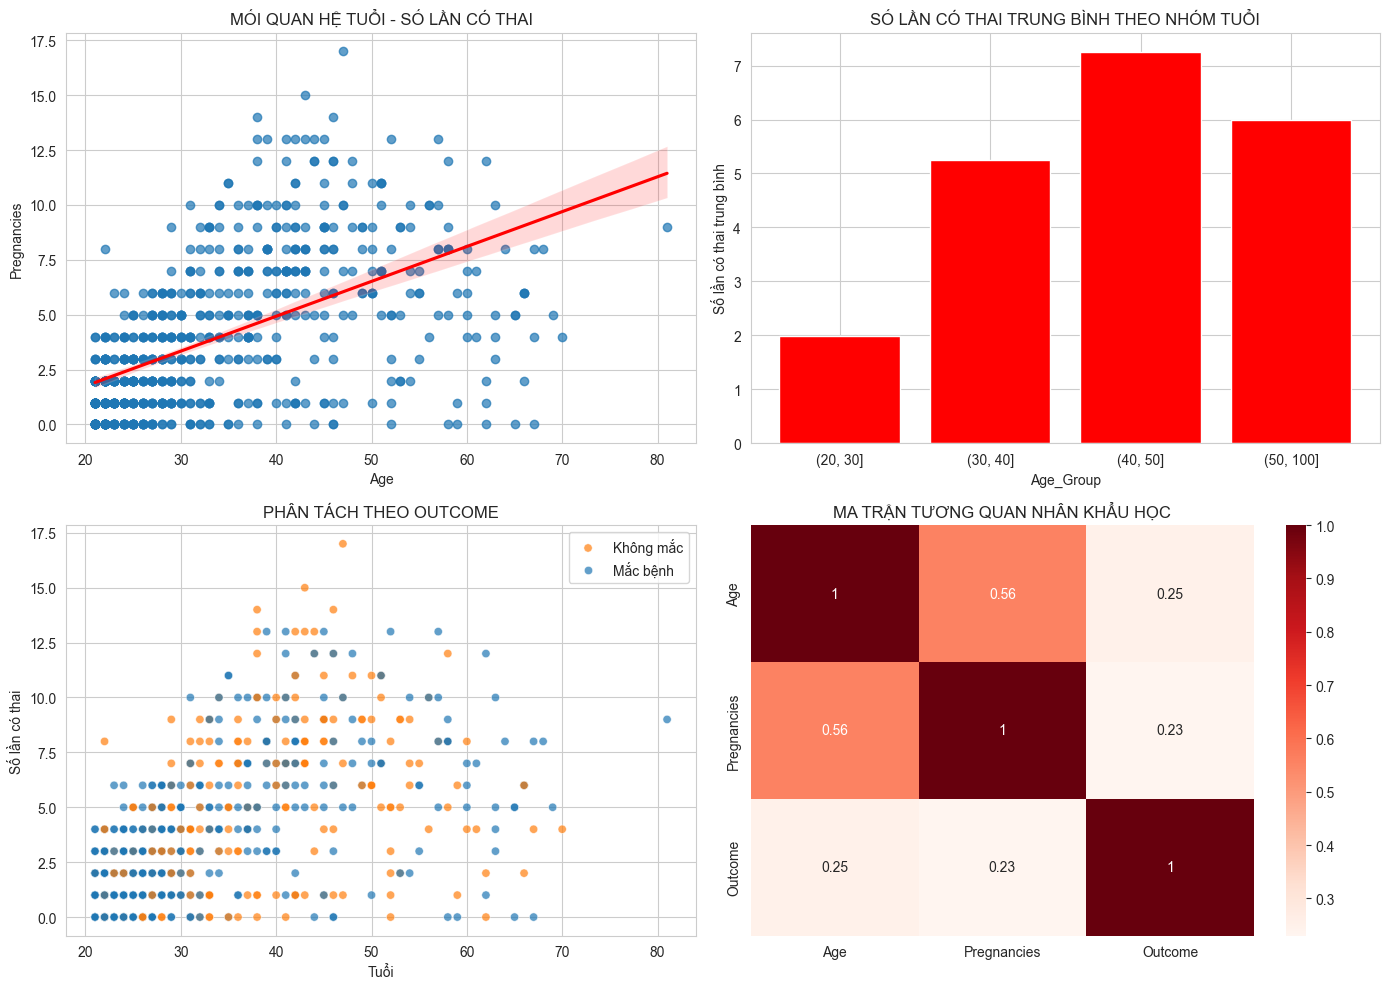

In [82]:
# 5.2.3. Tuổi - Số lần có thai

corr_age_preg = df_final[['Age', 'Pregnancies']].corr().iloc[0, 1]
print("\n5.2.3. Tuổi - Số lần có thai")
print(f"Hệ số tương quan Pearson: {corr_age_preg:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Scatter Age - Pregnancies
sns.regplot(data=df_final, x='Age', y='Pregnancies',
                scatter_kws={"alpha":0.7}, line_kws={"color":"red"}, ax=axes[0, 0])
axes[0, 0].set_title('MỐI QUAN HỆ TUỔI - SỐ LẦN CÓ THAI')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Pregnancies')

# 2) Số lần có thai trung bình theo nhóm tuổi
df_final['Age_Group'] = pd.cut(df_final['Age'], bins=[20, 30, 40, 50, 100], right=True)
mean_preg_by_age = df_final.groupby('Age_Group', observed=False)['Pregnancies'].mean()
axes[0, 1].bar([str(x) for x in mean_preg_by_age.index], mean_preg_by_age.values, color='red')
axes[0, 1].set_title('SỐ LẦN CÓ THAI TRUNG BÌNH THEO NHÓM TUỔI')
axes[0, 1].set_xlabel('Age_Group')
axes[0, 1].set_ylabel('Số lần có thai trung bình')

# 3) Phân tách theo Outcome
sns.scatterplot(data=df_final, x='Age', y='Pregnancies', hue='Outcome', ax=axes[1, 0], alpha=0.7)
axes[1, 0].set_title('PHÂN TÁCH THEO OUTCOME')
axes[1, 0].set_xlabel('Tuổi')
axes[1, 0].set_ylabel('Số lần có thai')
axes[1, 0].legend(title='', labels=['Không mắc', 'Mắc bệnh'])

# 4) Heatmap tương quan nhân khẩu học
demo_corr = df_final[['Age', 'Pregnancies', 'Outcome']].corr()
sns.heatmap(demo_corr, annot=True, cmap='Reds', ax=axes[1, 1])
axes[1, 1].set_title('MA TRẬN TƯƠNG QUAN NHÂN KHẨU HỌC')

plt.tight_layout()
plt.show()


5.2.4. Glucose - Insulin
Hệ số tương quan Pearson: 0.433


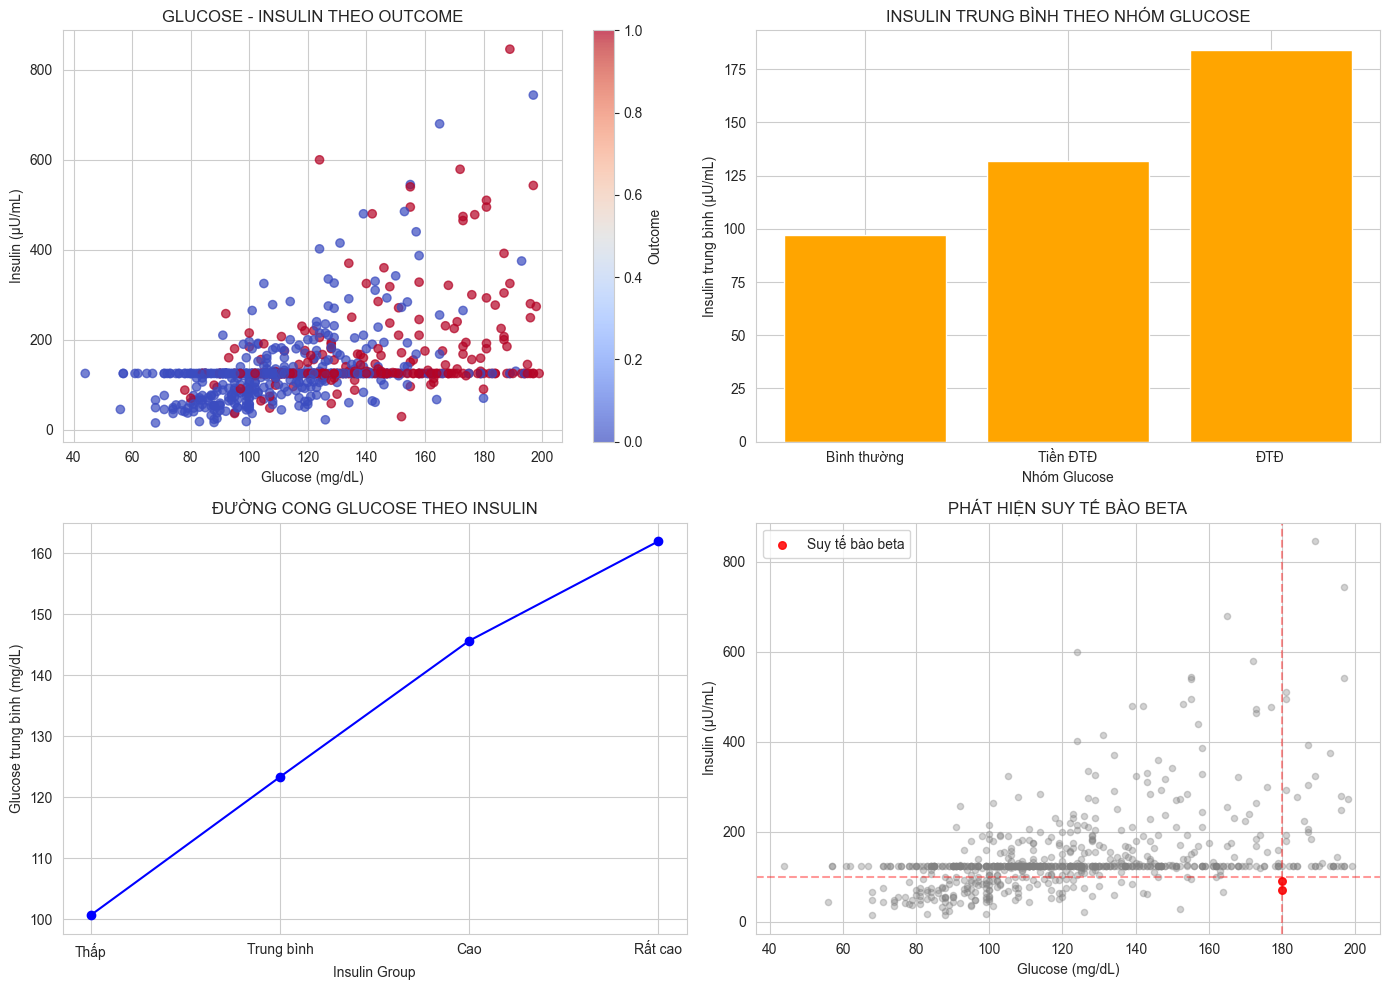

In [83]:
# 5.2.4. Glucose - Insulin

corr_glu_ins = df_final[['Glucose', 'Insulin']].corr().iloc[0, 1]
print("\n5.2.4. Glucose - Insulin")
print(f"Hệ số tương quan Pearson: {corr_glu_ins:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Scatter Glucose - Insulin theo Outcome với colorbar
sc = axes[0, 0].scatter(df_final['Glucose'], df_final['Insulin'],
                        c=df_final['Outcome'], cmap='coolwarm', alpha=0.7)
axes[0, 0].set_title('GLUCOSE - INSULIN THEO OUTCOME')
axes[0, 0].set_xlabel('Glucose (mg/dL)')
axes[0, 0].set_ylabel('Insulin (µU/mL)')
cbar = plt.colorbar(sc, ax=axes[0, 0])
cbar.set_label('Outcome')

# 2) Insulin trung bình theo nhóm Glucose
df_final['Glucose_Group'] = pd.cut(df_final['Glucose'], bins=[0, 100, 126, 200],
                                   labels=['Bình thường', 'Tiền ĐTĐ', 'ĐTĐ'], include_lowest=True)
mean_ins_by_glu = df_final.groupby('Glucose_Group', observed=False)['Insulin'].mean()
axes[0, 1].bar(mean_ins_by_glu.index.astype(str), mean_ins_by_glu.values, color='orange')
axes[0, 1].set_title('INSULIN TRUNG BÌNH THEO NHÓM GLUCOSE')
axes[0, 1].set_xlabel('Nhóm Glucose')
axes[0, 1].set_ylabel('Insulin trung bình (µU/mL)')

# 3) Đường cong Glucose theo Insulin
df_final['Insulin_Group'] = pd.cut(df_final['Insulin'], bins=[0, 100, 200, 400, 1000],
                                   labels=['Thấp', 'Trung bình', 'Cao', 'Rất cao'], include_lowest=True)
mean_glu_by_ins = df_final.groupby('Insulin_Group', observed=False)['Glucose'].mean()
axes[1, 0].plot(mean_glu_by_ins.index.astype(str), mean_glu_by_ins.values, color='blue', marker='o')
axes[1, 0].set_title('ĐƯỜNG CONG GLUCOSE THEO INSULIN')
axes[1, 0].set_xlabel('Insulin Group')
axes[1, 0].set_ylabel('Glucose trung bình (mg/dL)')

# 4) Phát hiện suy tế bào beta
axes[1, 1].scatter(df_final['Glucose'], df_final['Insulin'], color='gray', alpha=0.35, s=20)
beta_fail = (df_final['Glucose'] >= 180) & (df_final['Insulin'] <= 100)
axes[1, 1].scatter(df_final.loc[beta_fail, 'Glucose'],
                   df_final.loc[beta_fail, 'Insulin'],
                   color='red', alpha=0.85, s=30, label='Suy tế bào beta')
axes[1, 1].axvline(180, color='red', linestyle='--', alpha=0.4)
axes[1, 1].axhline(100, color='red', linestyle='--', alpha=0.4)
axes[1, 1].set_title('PHÁT HIỆN SUY TẾ BÀO BETA')
axes[1, 1].set_xlabel('Glucose (mg/dL)')
axes[1, 1].set_ylabel('Insulin (µU/mL)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

5.3.1. Tầm quan trọng đơn biến (C-square)

Bảng 5.1. Tập C-square
                 Feature  Chi_square  p_value
                 Glucose   13.370043 0.000256
                     Age    8.355644 0.003845
             Pregnancies    6.529960 0.010607
                     BMI    4.956279 0.025996
DiabetesPedigreeFunction    2.758259 0.096753
                 Insulin    2.497617 0.114019
           SkinThickness    1.231170 0.267180
           BloodPressure    0.602144 0.437761


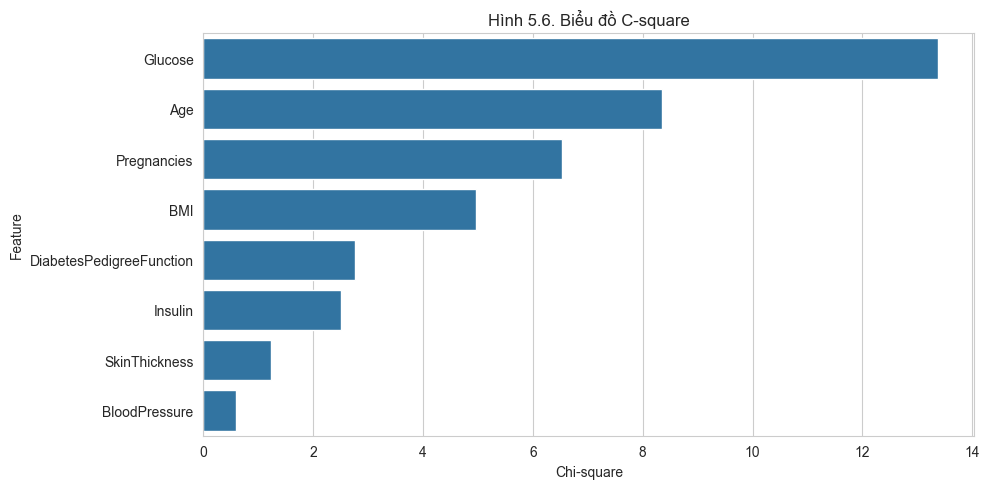


5.3.2. Điểm thông tin tương hỗ

Bảng 5.2. Thông tin tương hỗ
                 Feature  Mutual_Info
                 Glucose     0.114580
                     BMI     0.074008
                     Age     0.067678
             Pregnancies     0.041263
                 Insulin     0.030682
           BloodPressure     0.020572
           SkinThickness     0.010032
DiabetesPedigreeFunction     0.008157

Chỉ số Glucose là cao nhất.

5.3.3. Tầm quan trọng từ Random Forest

Bảng 5.3. Tầm quan trọng của đặc trưng
                 Feature  Importance
                 Glucose    0.245510
                     BMI    0.167327
                     Age    0.138257
DiabetesPedigreeFunction    0.119994
                 Insulin    0.097876
           BloodPressure    0.080915
             Pregnancies    0.076764
           SkinThickness    0.073359


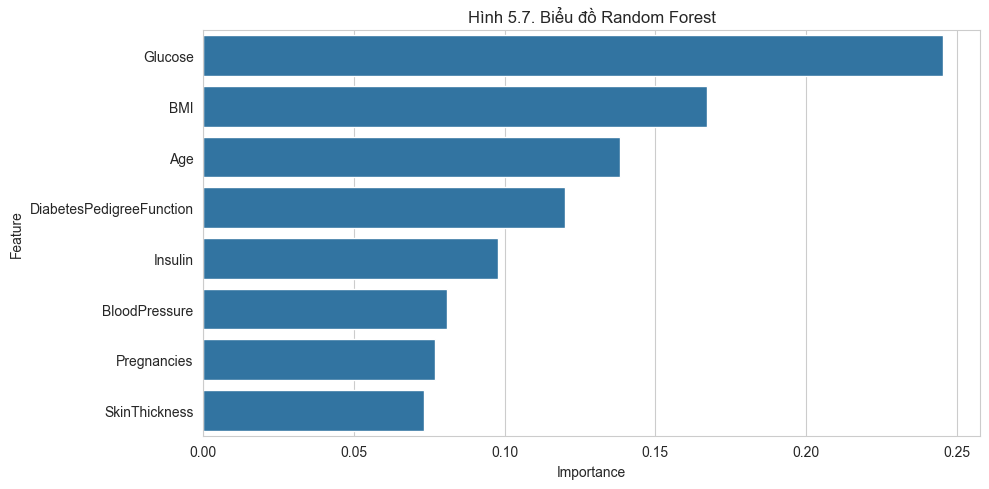

In [84]:
# 5.3 Phân tích tầm quan trọng của đặc trưng

sns.set_style("whitegrid")

base_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

df_model = df_final[base_cols + ['Outcome']].copy()
X = df_model[base_cols]
y = df_model['Outcome']

# 5.3.1. Tầm quan trọng đơn biến - C-square (chi-square)
print("5.3.1. Tầm quan trọng đơn biến (C-square)")

# chi2 yêu cầu dữ liệu không âm -> scale về [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

chi2_scores, chi2_pvals = chi2(X_scaled, y)

chi2_df = pd.DataFrame({
    'Feature': base_cols,
    'Chi_square': chi2_scores,
    'p_value': chi2_pvals
}).sort_values('Chi_square', ascending=False)

print("\nBảng 5.1. Tập C-square")
print(chi2_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=chi2_df, x='Chi_square', y='Feature')
plt.title('Hình 5.6. Biểu đồ C-square')
plt.xlabel('Chi-square')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 5.3.2. Điểm thông tin tương hỗ
print("\n5.3.2. Điểm thông tin tương hỗ")

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': base_cols,
    'Mutual_Info': mi_scores
}).sort_values('Mutual_Info', ascending=False)

print("\nBảng 5.2. Thông tin tương hỗ")
print(mi_df.to_string(index=False))

print(f"\nChỉ số {mi_df.iloc[0]['Feature']} là cao nhất.")

# 5.3.3. Tầm quan trọng từ Random Forest
print("\n5.3.3. Tầm quan trọng từ Random Forest")

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X, y)

rf_df = pd.DataFrame({
    'Feature': base_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nBảng 5.3. Tầm quan trọng của đặc trưng")
print(rf_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=rf_df, x='Importance', y='Feature')
plt.title('Hình 5.7. Biểu đồ Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


5.4. Phát hiện đa cộng tuyến

Bảng 5.1. Bảng hệ số phóng đại phương sai
                 Feature      VIF
                     Age 1.638908
                     BMI 1.564214
             Pregnancies 1.455605
           SkinThickness 1.453210
                 Glucose 1.369251
                 Insulin 1.270061
           BloodPressure 1.242440
DiabetesPedigreeFunction 1.040988


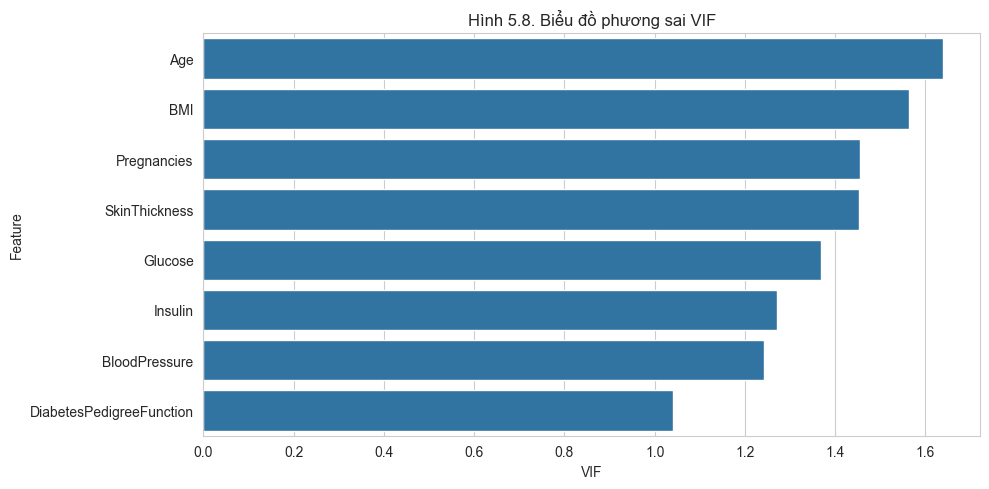

In [85]:
# 5.4. PHÁT HIỆN ĐA CỘNG TUYẾN - VIF

print("\n5.4. Phát hiện đa cộng tuyến")

X_vif = sm.add_constant(X)
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_df_no_const = vif_df[vif_df['Feature'] != 'const'].copy().sort_values('VIF', ascending=False)

print("\nBảng 5.1. Bảng hệ số phóng đại phương sai")
print(vif_df_no_const.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=vif_df_no_const, x='VIF', y='Feature')
plt.title('Hình 5.8. Biểu đồ phương sai VIF')
plt.xlabel('VIF')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Phân tích nâng cao

### Phân tích phân nhóm

In [86]:
def KMeans(n_clusters=3, random_state=42):
    from sklearn.cluster import KMeans
    return KMeans(n_clusters=n_clusters, random_state=random_state)

In [87]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df_final[["Glucose", "BMI"]]   # chỉ dùng 2 thuộc tính để vẽ

X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
df_final["Cluster"] = kmeans.fit_predict(X_scaled)

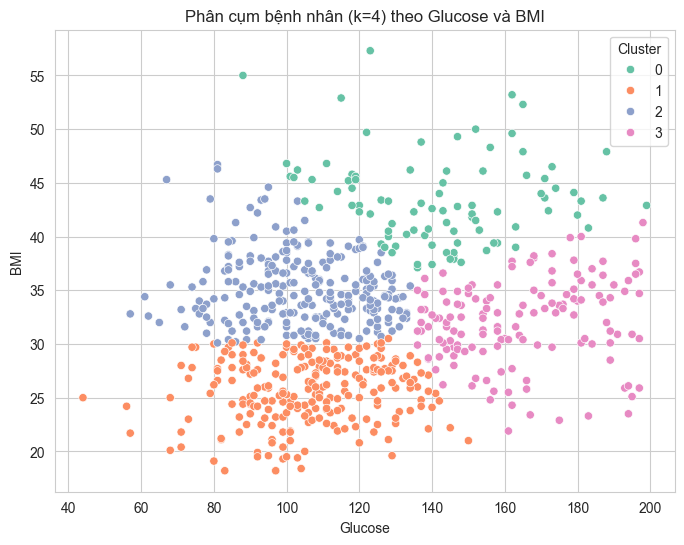

In [88]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_final,
    x="Glucose",
    y="BMI",
    hue="Cluster",
    palette="Set2"
)

plt.title("Phân cụm bệnh nhân (k=4) theo Glucose và BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")

plt.show()

In [89]:
# ================================
# THỐNG KÊ TỪNG CỤM
# ================================

for cluster in sorted(df_final["Cluster"].unique()):
    cluster_data = df_final[df_final["Cluster"] == cluster]
    
    count = len(cluster_data)
    percent = count / len(df_final) * 100
    
    age_mean = cluster_data["Age"].mean()
    age_std = cluster_data["Age"].std()
    
    bmi_mean = cluster_data["BMI"].mean()
    bmi_std = cluster_data["BMI"].std()
    
    glucose_mean = cluster_data["Glucose"].mean()
    glucose_std = cluster_data["Glucose"].std()
    
    # tỷ lệ mắc bệnh (Outcome = 1)
    disease_rate = cluster_data["Outcome"].mean() * 100

    print(f"\nCỤM {cluster} ({count} bệnh nhân - {percent:.1f}%):")
    print(f" - Tuổi trung bình: {age_mean:.1f} ± {age_std:.1f}")
    print(f" - BMI trung bình: {bmi_mean:.1f} ± {bmi_std:.1f}")
    print(f" - Glucose trung bình: {glucose_mean:.1f} ± {glucose_std:.1f}")
    print(f" - Tỷ lệ mắc bệnh: {disease_rate:.1f}%")


CỤM 0 (93 bệnh nhân - 12.9%):
 - Tuổi trung bình: 33.6 ± 10.4
 - BMI trung bình: 43.3 ± 4.1
 - Glucose trung bình: 142.1 ± 22.8
 - Tỷ lệ mắc bệnh: 61.3%

CỤM 1 (241 bệnh nhân - 33.4%):
 - Tuổi trung bình: 31.2 ± 12.2
 - BMI trung bình: 25.6 ± 3.0
 - Glucose trung bình: 106.2 ± 18.5
 - Tỷ lệ mắc bệnh: 12.9%

CỤM 2 (244 bệnh nhân - 33.8%):
 - Tuổi trung bình: 31.8 ± 9.8
 - BMI trung bình: 35.1 ± 3.3
 - Glucose trung bình: 104.3 ± 16.9
 - Tỷ lệ mắc bệnh: 25.4%

CỤM 3 (144 bệnh nhân - 19.9%):
 - Tuổi trung bình: 39.5 ± 12.9
 - BMI trung bình: 32.0 ± 3.9
 - Glucose trung bình: 164.4 ± 18.5
 - Tỷ lệ mắc bệnh: 67.4%


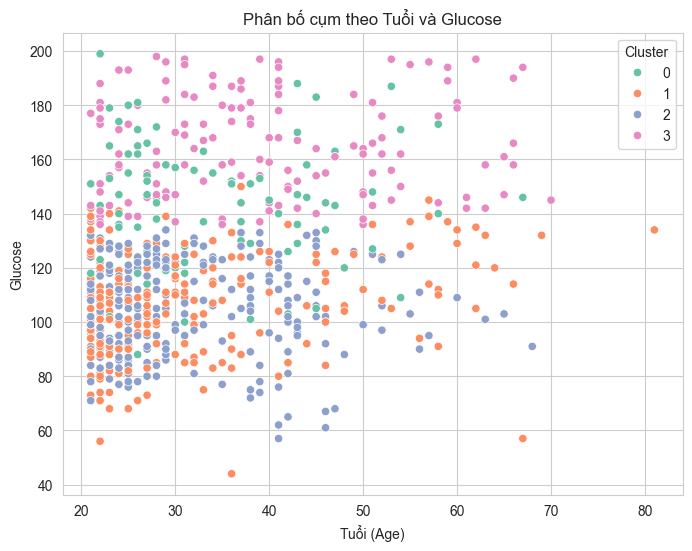

In [90]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_final,
    x="Age",
    y="Glucose",
    hue="Cluster",
    palette="Set2"
)

plt.title("Phân bố cụm theo Tuổi và Glucose")
plt.xlabel("Tuổi (Age)")
plt.ylabel("Glucose")

plt.show()

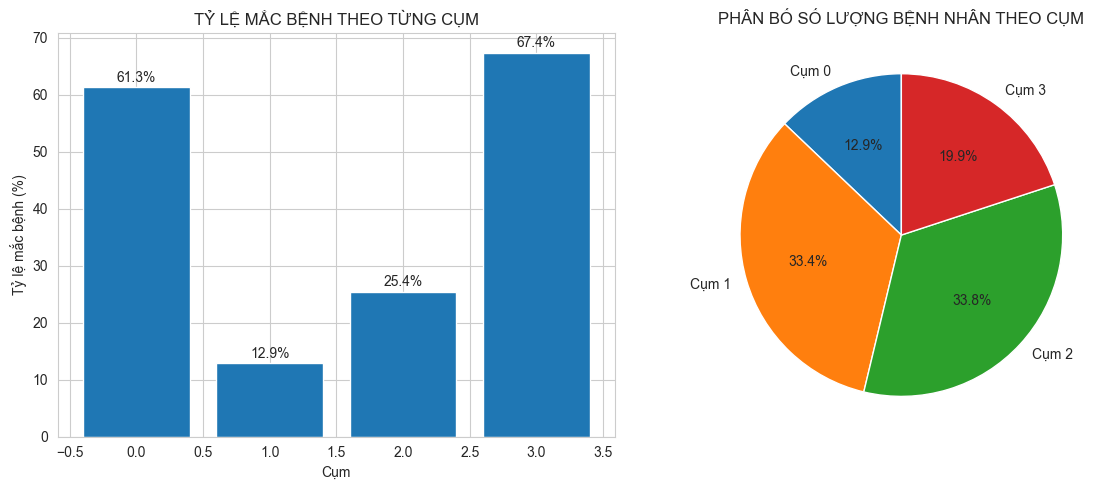

In [91]:
cluster_stats = df_final.groupby("Cluster").agg({
    "Outcome": "mean",   # tỷ lệ bệnh
    "Age": "count"       # số lượng
}).rename(columns={"Age": "Count"})

# chuyển sang %
cluster_stats["DiseaseRate"] = cluster_stats["Outcome"] * 100

# ================================
# VẼ BIỂU ĐỒ
# ================================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --------- BIỂU ĐỒ CỘT ---------
axes[0].bar(cluster_stats.index, cluster_stats["DiseaseRate"])

axes[0].set_title("TỶ LỆ MẮC BỆNH THEO TỪNG CỤM")
axes[0].set_xlabel("Cụm")
axes[0].set_ylabel("Tỷ lệ mắc bệnh (%)")

# hiển thị số trên cột
for i, v in enumerate(cluster_stats["DiseaseRate"]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha='center')

# --------- PIE CHART ---------
axes[1].pie(
    cluster_stats["Count"],
    labels=[f"Cụm {i}" for i in cluster_stats.index],
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("PHÂN BỐ SỐ LƯỢNG BỆNH NHÂN THEO CỤM")

plt.tight_layout()
plt.show()

### Phân tích các yếu tố nguy cơ

In [97]:
print(df_final.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


In [100]:
import statsmodels.api as sm
from IPython.display import display

# ====== DATA CỦA BẠN ======
df_final = pd.read_csv("iris_eda-data/pima-indians-diabetes.data.csv",names=columns)

X = df_final.drop("Outcome", axis=1)
y = df_final["Outcome"]

# Logistic Regression
X = sm.add_constant(X)
model = sm.Logit(y, X).fit(disp=0)

params = model.params
conf = model.conf_int()

# ====== TẠO BẢNG ======
or_df = pd.DataFrame({
    "Yếu tố nguy cơ": params.index,
    "OR": np.exp(params),
    "CI thấp": np.exp(conf[0]),
    "CI cao": np.exp(conf[1]),
    "P-value": model.pvalues
})

# bỏ const
or_df = or_df.drop("const")

# ====== PHÂN LOẠI NGUY CƠ ======
def classify_or(or_val, p):
    if p >= 0.05:
        return "Không ý nghĩa"
    elif or_val >= 3:
        return "Nguy cơ rất cao"
    elif or_val >= 2:
        return "Nguy cơ cao"
    elif or_val >= 1:
        return "Nguy cơ trung bình"
    else:
        return "Bảo vệ"

or_df["Phân loại"] = or_df.apply(lambda row: classify_or(row["OR"], row["P-value"]), axis=1)

# ====== THÊM NGƯỠNG (giống bài bạn) ======
thresholds = {
    "Glucose": 126,
    "BMI": 35,
    "Age": 45,
    "Pregnancies": 4,
    "DiabetesPedigreeFunction": 0.5,
    "BloodPressure": 90,
    "Insulin": 166,
    "SkinThickness": 30
}

or_df["Ngưỡng"] = or_df["Yếu tố nguy cơ"].map(thresholds)

# ====== SẮP XẾP CHO ĐẸP ======
or_df = or_df[[
    "Yếu tố nguy cơ",
    "Ngưỡng",
    "OR",
    "CI thấp",
    "CI cao",
    "P-value",
    "Phân loại"
]]

# làm tròn giống báo cáo
or_df = or_df.round({
    "OR": 2,
    "CI thấp": 2,
    "CI cao": 2,
    "P-value": 4
})

print("\n=== BẢNG ODDS RATIO HOÀN CHỈNH ===")
display(or_df)


=== BẢNG ODDS RATIO HOÀN CHỈNH ===


,Yếu tố nguy cơ,Ngưỡng,OR,CI thấp,CI cao,P-value,Phân loại
Pregnancies,Pregnancies,4.0,1.13,1.06,1.20,0.0001,Nguy cơ trung bình
Glucose,Glucose,126.0,1.04,1.03,1.04,0.0000,Nguy cơ trung bình
BloodPressure,BloodPressure,90.0,0.99,0.98,1.00,0.0111,Bảo vệ
SkinThickness,SkinThickness,30.0,1.00,0.99,1.01,0.9285,Không ý nghĩa
Insulin,Insulin,166.0,1.00,1.00,1.00,0.1861,Không ý nghĩa
BMI,BMI,35.0,1.09,1.06,1.13,0.0000,Nguy cơ trung bình
DiabetesPedigreeFunction,DiabetesPedigreeFunction,0.5,2.57,1.43,4.63,0.0016,Nguy cơ cao
Age,Age,45.0,1.01,1.00,1.03,0.1112,Không ý nghĩa


In [101]:
# ====== 1. TẠO ĐIỂM NGUY CƠ ======
def calculate_score(row):
    score = 0
    
    if row["Glucose"] >= 126: score += 4
    if row["BMI"] >= 35: score += 2
    if row["Age"] >= 45: score += 2
    if row["Pregnancies"] >= 4: score += 2
    if row["DiabetesPedigreeFunction"] >= 0.5: score += 2
    if row["BloodPressure"] >= 90: score += 1
    if row["Insulin"] >= 166: score += 2
    if row["SkinThickness"] >= 30: score += 1

    return score

df_final["RiskScore"] = df_final.apply(calculate_score, axis=1)

# ====== 2. PHÂN LOẠI ======
def classify(score):
    if score <= 3:
        return "Nguy cơ thấp"
    elif score <= 6:
        return "Nguy cơ vừa"
    elif score <= 9:
        return "Nguy cơ cao"
    else:
        return "Nguy cơ rất cao"

df_final["RiskLevel"] = df_final["RiskScore"].apply(classify)

# ====== 3. TẠO BẢNG THANG ĐIỂM (GIỐNG HÌNH) ======
score_table = pd.DataFrame({
    "Yếu tố nguy cơ": [
        "Glucose ≥ 126",
        "BMI ≥ 35",
        "Age ≥ 45",
        "Pregnancies ≥ 4",
        "DiabetesPedigreeFunction ≥ 0.5",
        "BloodPressure ≥ 90",
        "Insulin ≥ 166",
        "SkinThickness ≥ 30"
    ],
    "Điểm": [4, 2, 2, 2, 2, 1, 2, 1]
})

print("\n=== BẢNG THANG ĐIỂM NGUY CƠ ===")
print(score_table.to_string(index=False))


=== BẢNG THANG ĐIỂM NGUY CƠ ===
                Yếu tố nguy cơ  Điểm
                 Glucose ≥ 126     4
                      BMI ≥ 35     2
                      Age ≥ 45     2
               Pregnancies ≥ 4     2
DiabetesPedigreeFunction ≥ 0.5     2
            BloodPressure ≥ 90     1
                 Insulin ≥ 166     2
            SkinThickness ≥ 30     1


In [102]:
# ====== 1. PHÂN LOẠI THEO ĐIỂM ======
def classify(score):
    if score <= 3:
        return "Nguy cơ thấp (0 - 3)"
    elif score <= 6:
        return "Nguy cơ vừa (4 - 6)"
    elif score <= 9:
        return "Nguy cơ cao (7 - 9)"
    else:
        return "Nguy cơ rất cao (≥ 10)"

df_final["RiskLevel"] = df_final["RiskScore"].apply(classify)

# ====== 2. TẠO BẢNG THỐNG KÊ ======
summary = df_final.groupby("RiskLevel").agg(
    Tỷ_Lệ_Mắc_Bệnh =("Outcome", "mean"),
    Số_Lượng_BệnhNhân=("Outcome", "count")
).reset_index()

# đổi sang %
summary["Tỷ_Lệ_Mắc_Bệnh"] = summary["Tỷ_Lệ_Mắc_Bệnh"] * 100

# ====== 3. SẮP XẾP THỨ TỰ ======
order = ["Nguy cơ thấp (0 - 3)","Nguy cơ vừa (4 - 6)","Nguy cơ cao (7 - 9)","Nguy cơ rất cao (≥ 10)"]
summary["RiskLevel"] = pd.Categorical(summary["RiskLevel"], categories=order, ordered=True)
summary = summary.sort_values("RiskLevel")

# làm tròn đẹp
summary["Tỷ_Lệ_Mắc_Bệnh"] = summary["Tỷ_Lệ_Mắc_Bệnh"].round(1)

print("\n=== BẢNG PHÂN LOẠI NGUY CƠ ===")
print(summary.to_string(index=False))


=== BẢNG PHÂN LOẠI NGUY CƠ ===
             RiskLevel  Tỷ_Lệ_Mắc_Bệnh  Số_Lượng_BệnhNhân
  Nguy cơ thấp (0 - 3)            12.8                312
   Nguy cơ vừa (4 - 6)            33.8                204
   Nguy cơ cao (7 - 9)            60.9                161
Nguy cơ rất cao (≥ 10)            67.0                 91


In [103]:
from sklearn.metrics import roc_curve, auc
# các biến cần phân tích
features = ["Glucose", "BMI", "Age", "RiskScore"]

roc_results = []

for col in features:
    scores = df_final[col]
    
    fpr, tpr, thresholds = roc_curve(y, scores)
    roc_auc = auc(fpr, tpr)
    
    # Youden Index (tìm ngưỡng tối ưu)
    J = tpr - fpr
    ix = np.argmax(J)
    
    best_threshold = thresholds[ix]
    sensitivity = tpr[ix]
    specificity = 1 - fpr[ix]
    
    roc_results.append([
        col,
        roc_auc,
        best_threshold,
        sensitivity,
        specificity
    ])

# ====== TẠO BẢNG ======
roc_table = pd.DataFrame(roc_results, columns=[
    "Biến",
    "AUC",
    "Ngưỡng tối ưu",
    "Độ nhạy",
    "Đặc hiệu"
])

# làm tròn đẹp
roc_table = roc_table.round({
    "AUC": 2,
    "Ngưỡng tối ưu": 2,
    "Độ nhạy": 2,
    "Độ đặc hiệu": 2
})

print("\n=== BẢNG ROC ===")
print(roc_table.to_string(index=False))


=== BẢNG ROC ===
     Biến  AUC  Ngưỡng tối ưu  Độ nhạy  Đặc hiệu
  Glucose 0.79          124.0     0.70     0.732
      BMI 0.69           29.9     0.82     0.488
      Age 0.69           29.0     0.74     0.592
RiskScore 0.77            6.0     0.68     0.728


In [105]:
import pandas as pd
import numpy as np
from IPython.display import display

# Cột glucose và kết quả (Outcome: 0/1)
glucose = df_final["Glucose"]
y_true = df_final["Outcome"]

# Các ngưỡng cần xét
thresholds = [100, 110, 120, 130, 140, 150, 160]

# Hàm tính các chỉ số
def compute_metrics(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    ppv = TP / (TP + FP) if (TP + FP) != 0 else 0
    npv = TN / (TN + FN) if (TN + FN) != 0 else 0
    accuracy = (TP + TN) / len(y_true)

    return sensitivity, specificity, ppv, npv, accuracy


# Tạo bảng kết quả
results = []

for t in thresholds:
    y_pred = (glucose >= t).astype(int)

    sens, spec, ppv, npv, acc = compute_metrics(y_true, y_pred)

    results.append([
        f">={t} mg/dL",
        round(sens * 100, 1),
        round(spec * 100, 1),
        round(ppv * 100, 1),
        round(npv * 100, 1),
        round(acc * 100, 1)
    ])

# Xuất bảng
columns = ["Ngưỡng", "Độ nhạy (%)", "Độ đặc hiệu (%)", "PPV (%)", "NPV (%)", "Độ chính xác (%)"]
result_df = pd.DataFrame(results, columns=columns)

display(result_df)

,Ngưỡng,Độ nhạy (%),Độ đặc hiệu (%),PPV (%),NPV (%),Độ chính xác (%)
0,>=100 mg/dL,94.0,36.2,44.1,91.9,56.4
1,>=110 mg/dL,83.6,54.0,49.3,86.0,64.3
2,>=120 mg/dL,73.9,67.6,55.0,82.8,69.8
3,>=130 mg/dL,60.4,80.8,62.8,79.2,73.7
4,>=140 mg/dL,50.4,87.6,68.5,76.7,74.6
5,>=150 mg/dL,39.6,92.6,74.1,74.1,74.1
6,>=160 mg/dL,31.3,96.4,82.4,72.4,73.7


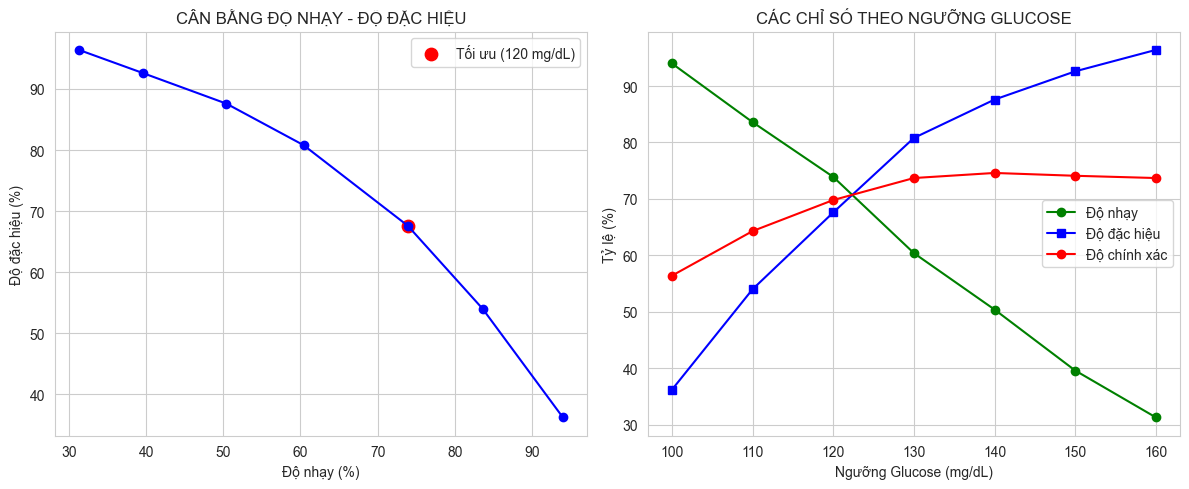

In [ ]:
import matplotlib.pyplot as plt

# ====== LẤY DATA TỪ result_df ======
thresholds = result_df["Ngưỡng"].str.extract('(\d+)').astype(int)[0].values
sens = result_df["Độ nhạy (%)"].values
spec = result_df["Độ đặc hiệu (%)"].values
acc = result_df["Độ chính xác (%)"].values

# ====== TÌM ĐIỂM TỐI ƯU ======
opt_idx = (sens + spec).argmax()

# ====== VẼ ======
plt.figure(figsize=(12,5))

# ====== BIỂU ĐỒ 1: Sens vs Spec ======
plt.subplot(1,2,1)

plt.plot(sens, spec, marker='o', color='blue')
plt.scatter(sens[opt_idx], spec[opt_idx], color='red', s=80,
            label=f"Tối ưu ({thresholds[opt_idx]} mg/dL)")

plt.xlabel("Độ nhạy (%)")
plt.ylabel("Độ đặc hiệu (%)")
plt.title("CÂN BẰNG ĐỘ NHẠY - ĐỘ ĐẶC HIỆU")
plt.legend()
plt.grid(True)

# ====== BIỂU ĐỒ 2: Theo ngưỡng ======
plt.subplot(1,2,2)

plt.plot(thresholds, sens, marker='o', color='green', label="Độ nhạy")
plt.plot(thresholds, spec, marker='s', color='blue', label="Độ đặc hiệu")
plt.plot(thresholds, acc, marker='o', color='red', label="Độ chính xác")

plt.xlabel("Ngưỡng Glucose (mg/dL)")
plt.ylabel("Tỷ lệ (%)")
plt.title("CÁC CHỈ SỐ THEO NGƯỠNG GLUCOSE")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Kết thúc